In [26]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Arial"


logs/Full_LQR/hist_stereo_mm/setpoint_5000_0.90_0.90_0.90
5045.645


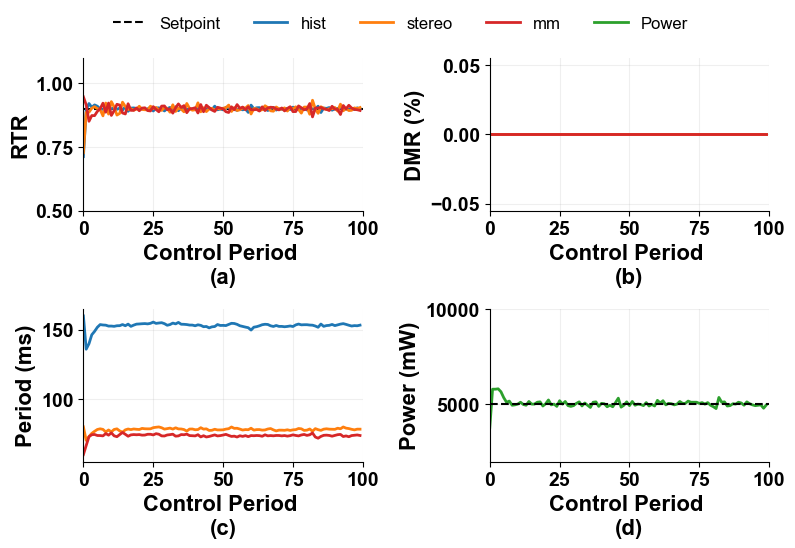

logs/Full_LQR/hist_stereo_mm/setpoint_6000_0.90_0.90_0.90
6005.04


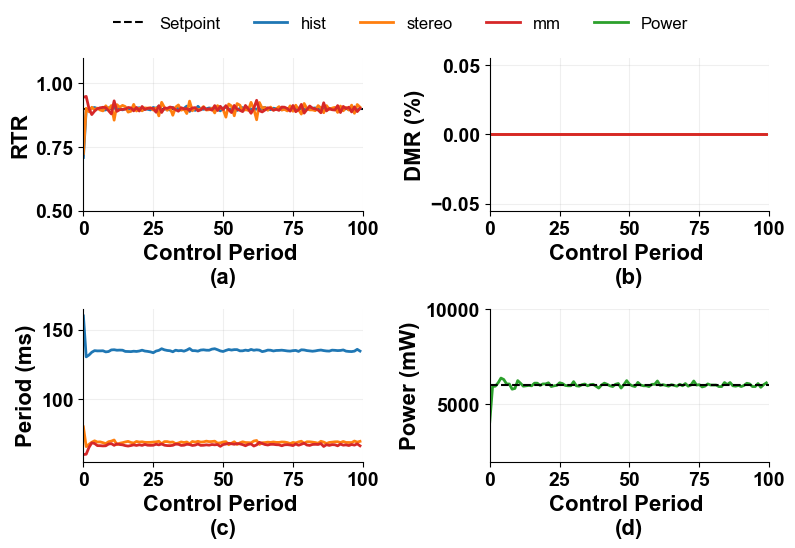

logs/Full_LQR/hist_stereo_mm/setpoint_7000_0.90_0.90_0.90
6951.085


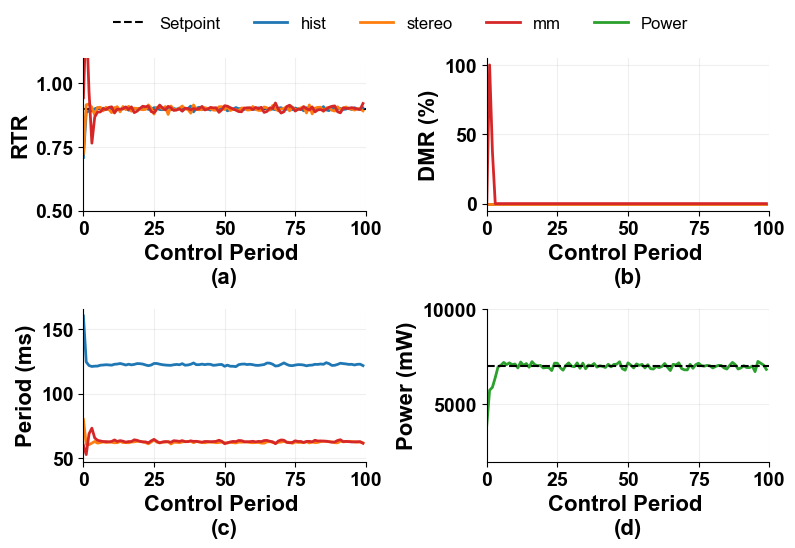

logs/Full_LQR/hist_stereo_mm/setpoint_5000_0.80_0.80_0.80
5037.575


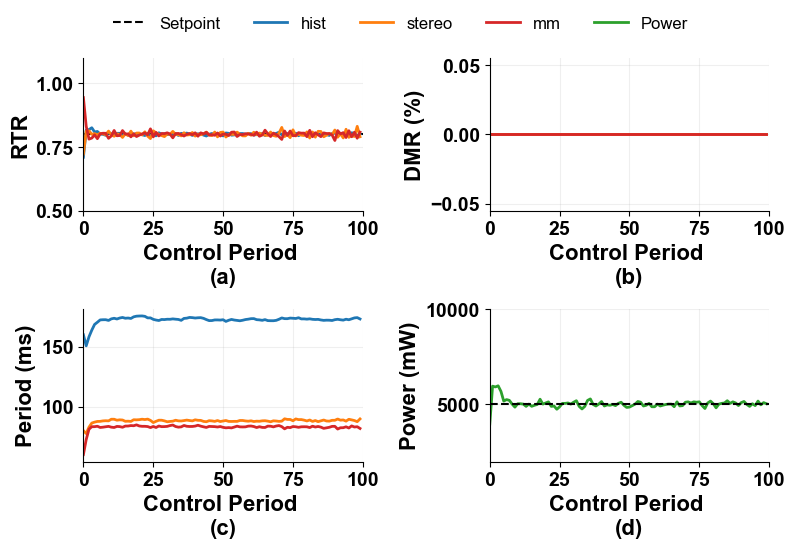

logs/Full_LQR/hist_stereo_mm/setpoint_6000_0.80_0.80_0.80
6013.06


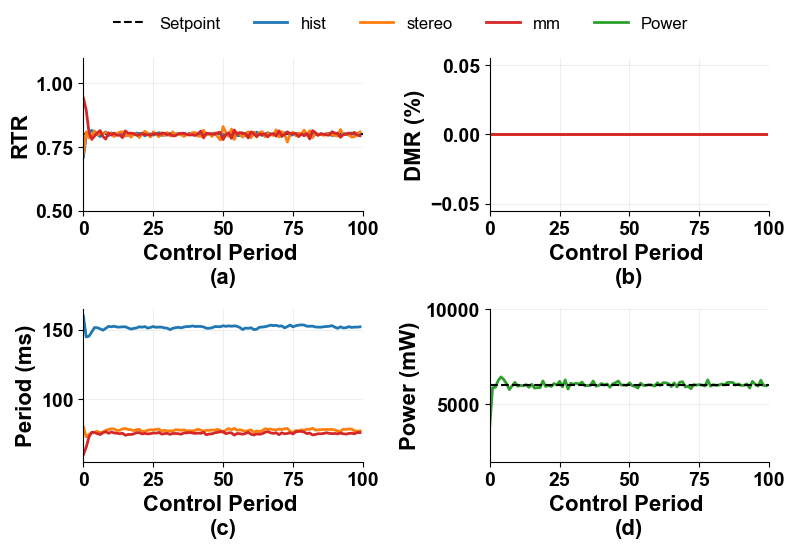

logs/Full_LQR/hist_stereo_mm/setpoint_7000_0.80_0.80_0.80
6961.87


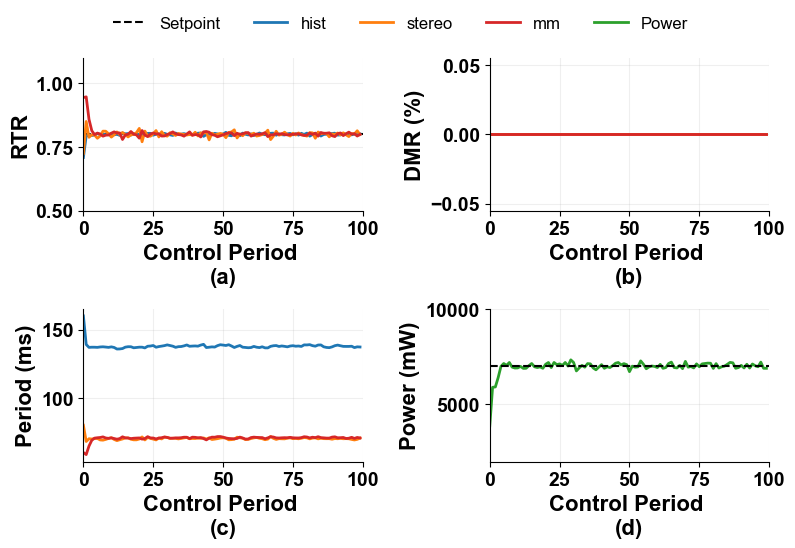

logs/Full_LQR/hist_stereo_mm/setpoint_5000_0.70_0.70_0.70
5037.665


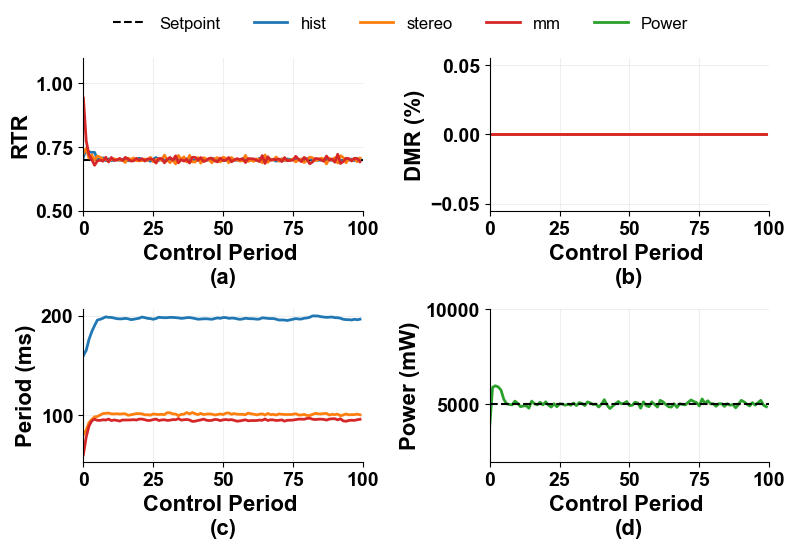

logs/Full_LQR/hist_stereo_mm/setpoint_6000_0.70_0.70_0.70
6016.555


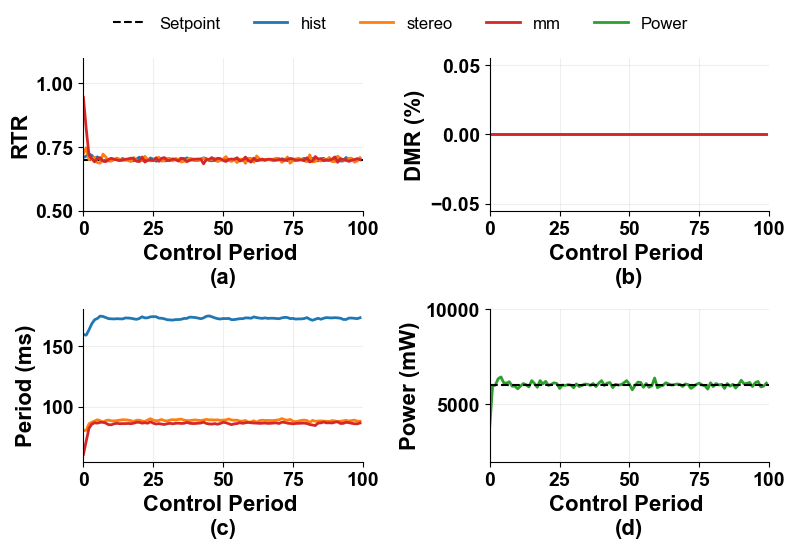

logs/Full_LQR/hist_stereo_mm/setpoint_7000_0.70_0.70_0.70
6967.455


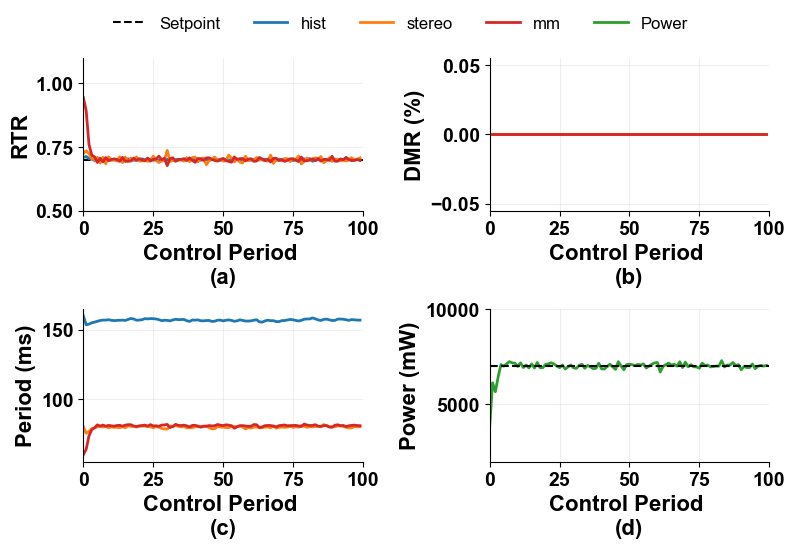

In [27]:
################FULL LQR
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.weight"] = "normal"


# --------- CONFIG ----------
root = Path("logs/Full_LQR/hist_stereo_mm/")  
#root = Path("Proposed_bounds/histogram_converted_stereodisparity_converted_mm_converted/") 
#oot = Path("LQR/hist_stereo_mm/") 
setpoints = [0.90, 0.80, 0.70]
p_setpoint = [5000, 6000, 7000]
warmup_skip = 0         
max_periods = 100  
save_path = Path("figures")
task_names = ["hist", "stereo", "mm"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
FIGSIZE = (10, 8)
FIGSIZE = (8, 6)
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 14
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    for power in p_setpoint:
        run_dir = root / f"setpoint_{power}_{sp:.2f}_{sp:.2f}_{sp:.2f}"
        #run_dir = root / f"setpoint_{sp:.2f}"
        print(run_dir)
        data = {name: {} for name in task_names}
        for i, name in enumerate(task_names, 1):
            t_id = f"t{i}"
            data[name]['rtr'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_rtr.txt"), warmup_skip, max_periods)
            data[name]['dl']  = slice_idx(read_data(run_dir / f"Proposed_{t_id}_deadline.txt"), warmup_skip, max_periods)
            data[name]['per'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_period.txt"), warmup_skip, max_periods)
            data[name]['low'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
            data[name]['high']= slice_idx(read_data(run_dir / f"Proposed_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

        pwrs = slice_idx(read_data(run_dir / "Proposed_finalpowervalues.txt"), warmup_skip, max_periods)

        fig, axs = plt.subplots(2, 2, figsize=FIGSIZE)
        axs = axs.flatten()
        
        # (1) RTR
        ax = axs[0]
        ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        for name, color in zip(task_names, task_colors):
            if data[name]['rtr'] is not None:
                ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
        ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim(0.5, 1.1)

        # (2) Deadline
        ax = axs[1]
        for name, color in zip(task_names, task_colors):
            if data[name]['dl'] is not None:
                ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
        ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        ax = axs[2]
        for name, color in zip(task_names, task_colors):
            if data[name]['per'] is not None:
                ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
            if data[name]['low'] is not None:
                #ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
            if data[name]['high'] is not None:
                #ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
        ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        # (4) Power
        ax = axs[3]
        if pwrs is not None:
            ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
        print(np.mean(pwrs))
        ax.set_ylabel("Power (mW)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.axhline(y=power, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        ax.set_ylim([2000,10000])

        # Global Styling
        for ax in axs:
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
            for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, alpha=0.2)
            ax.set_xlim([0,100])


        handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
        power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
        handles.append(power_handle)
        labels.append("Power")
#         bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
#         handles.append(bound_handle)
#         labels.append("Bounds")

        fig.legend(
            handles, 
            labels, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 0.92),  
            ncol=len(labels), 
            frameon=False, 
            prop={ 'size': 12} 
        )   
        plt.tight_layout(rect=[0, 0, 1, 0.85]) 

        save_path.mkdir(exist_ok=True)
        plt.savefig(save_path /f"LQR_setpoint_{power}_{sp:.2f}.pdf", bbox_inches='tight')
        plt.show()

logs/Full_FC/hist_stereo_mm/setpoint_5000_0.90_0.90_0.90
5894.955


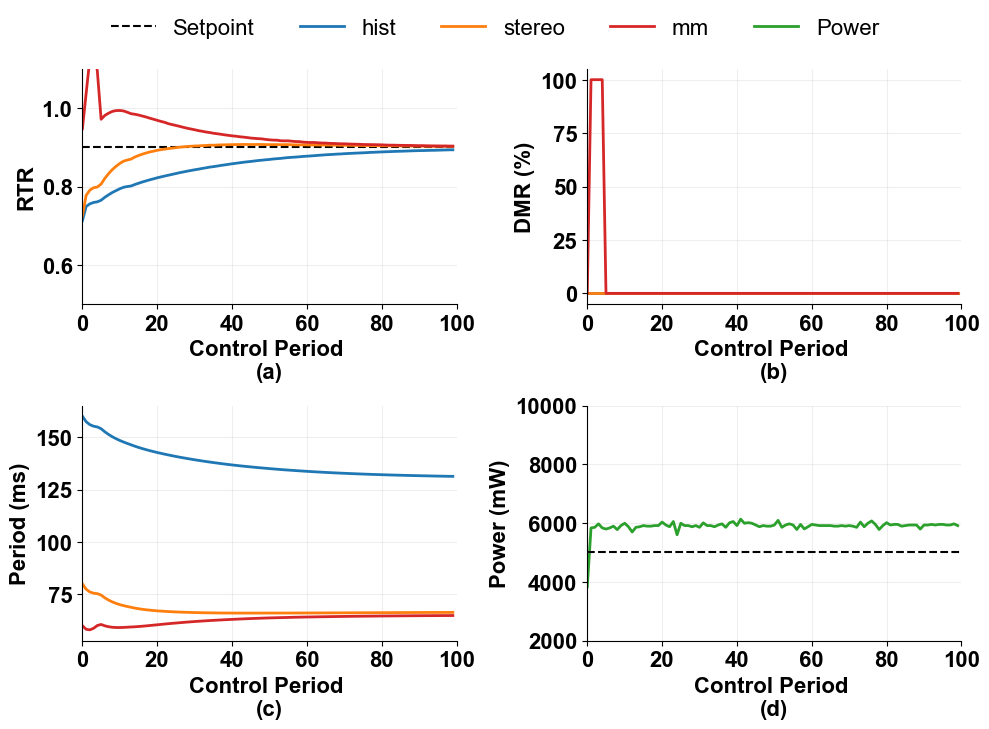

logs/Full_FC/hist_stereo_mm/setpoint_6000_0.90_0.90_0.90
5910.555


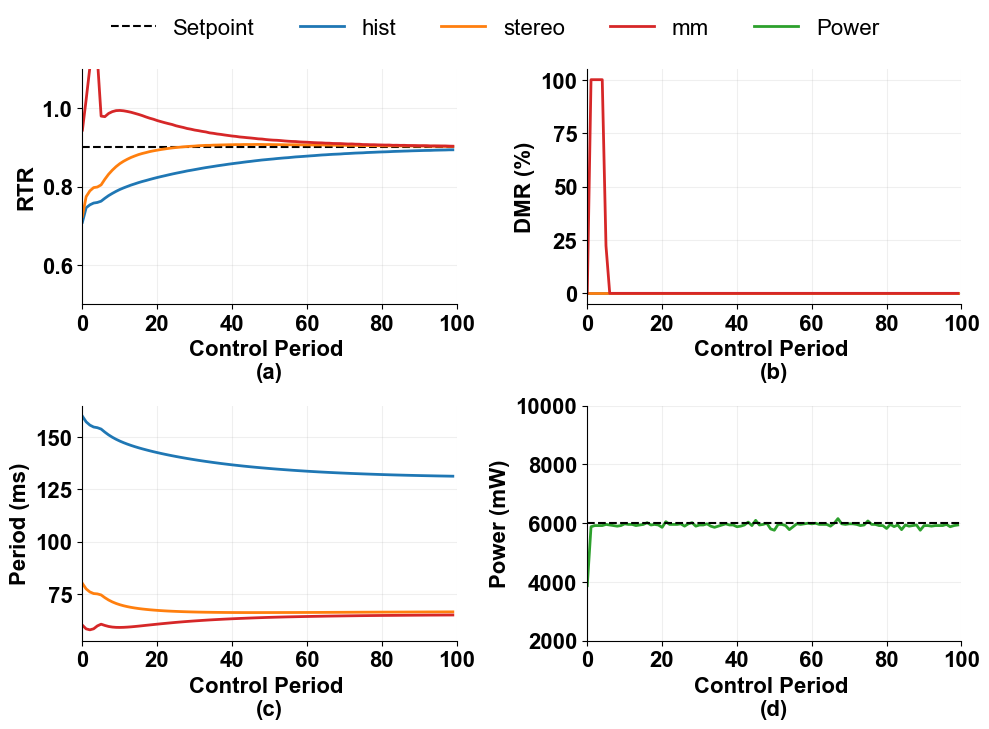

logs/Full_FC/hist_stereo_mm/setpoint_7000_0.90_0.90_0.90
5933.485


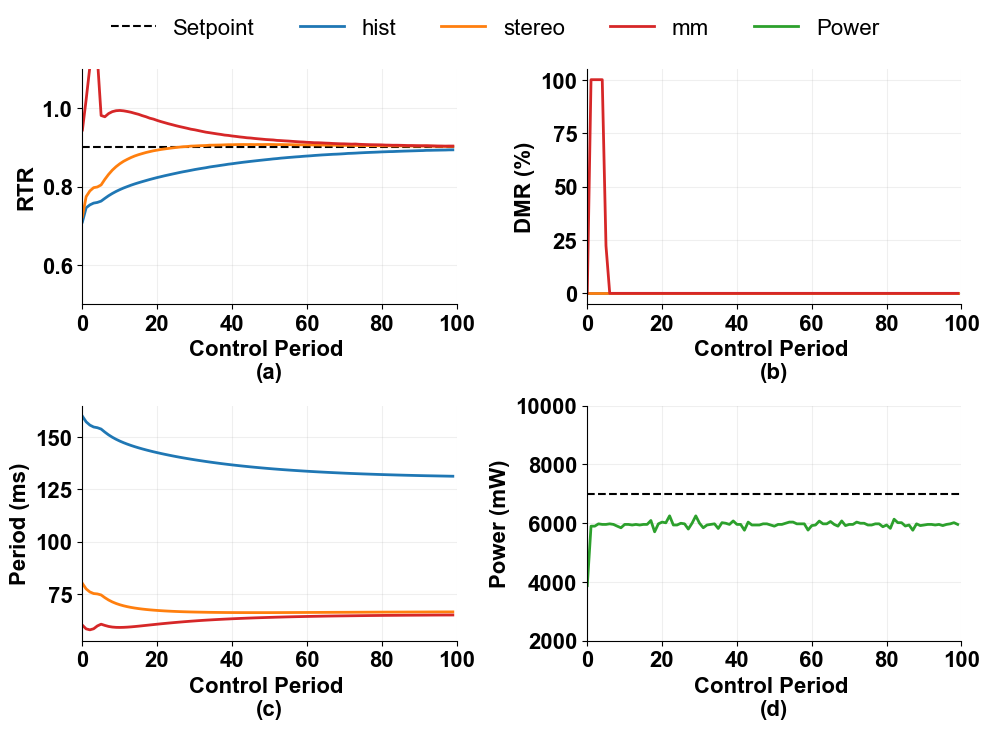

logs/Full_FC/hist_stereo_mm/setpoint_5000_0.80_0.80_0.80
5921.335


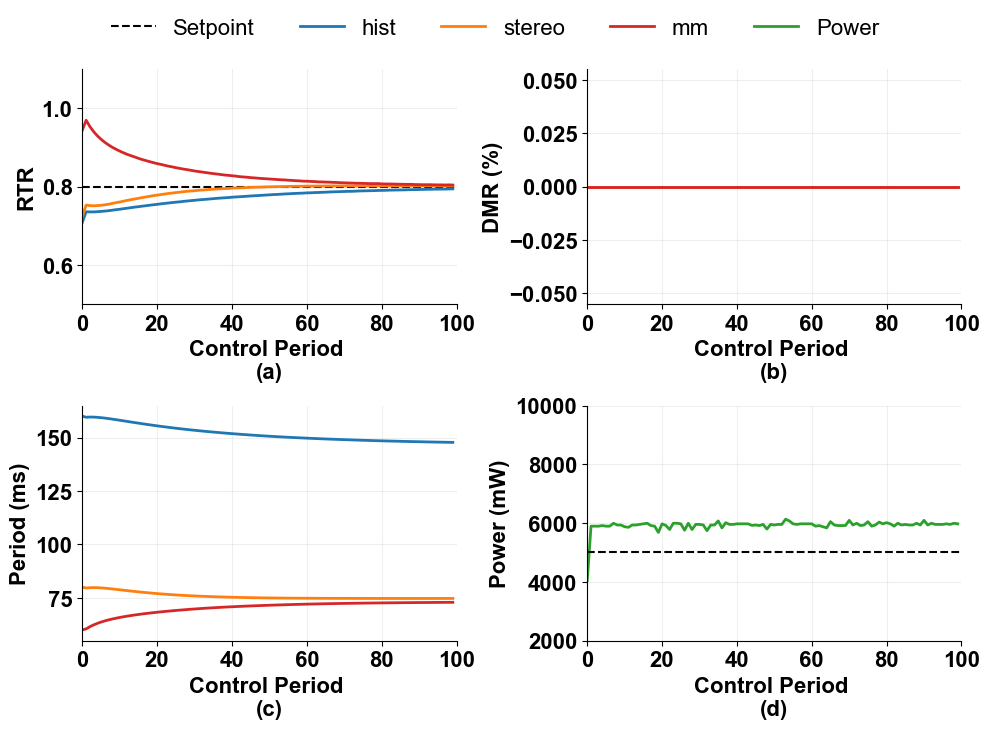

logs/Full_FC/hist_stereo_mm/setpoint_6000_0.80_0.80_0.80
5924.545


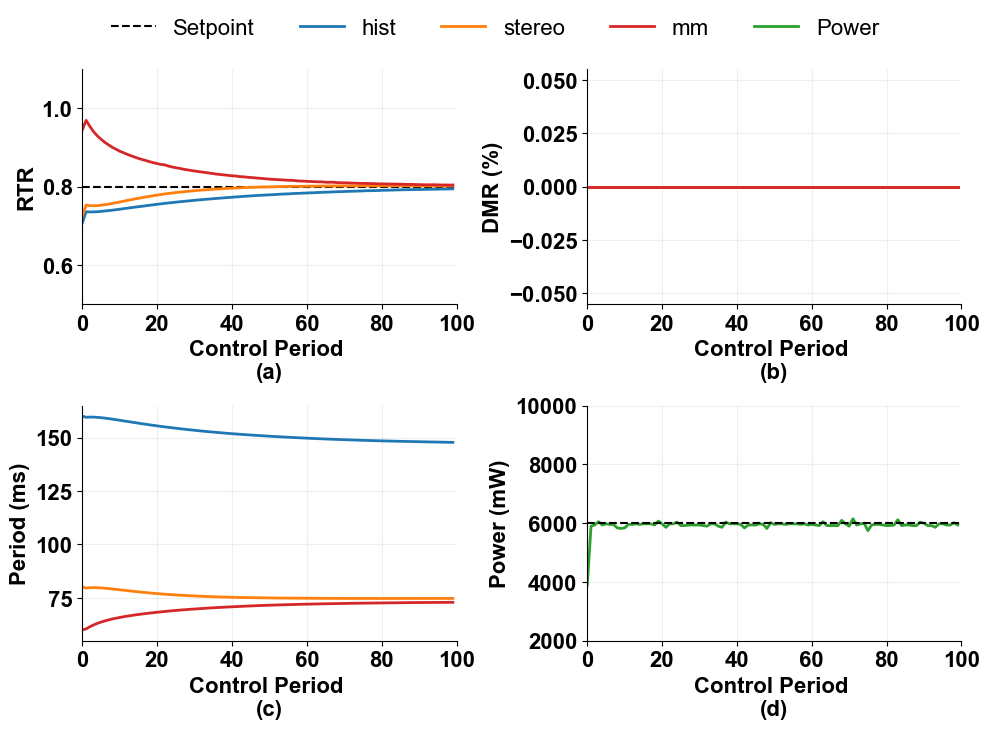

logs/Full_FC/hist_stereo_mm/setpoint_7000_0.80_0.80_0.80
5914.435


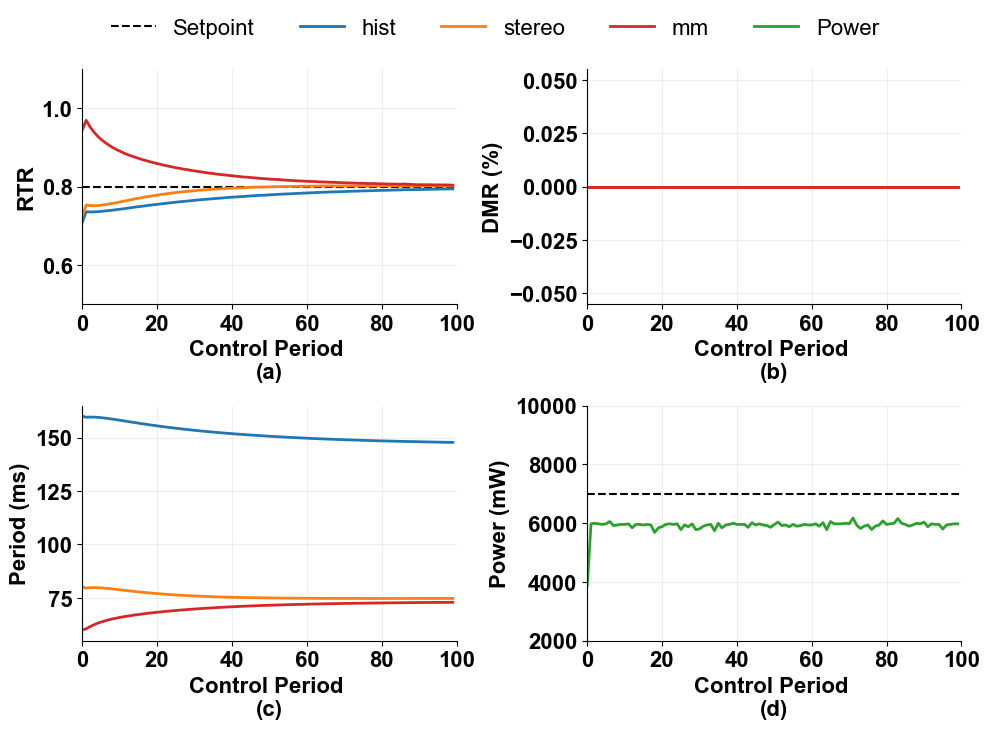

logs/Full_FC/hist_stereo_mm/setpoint_5000_0.70_0.70_0.70
5929.03


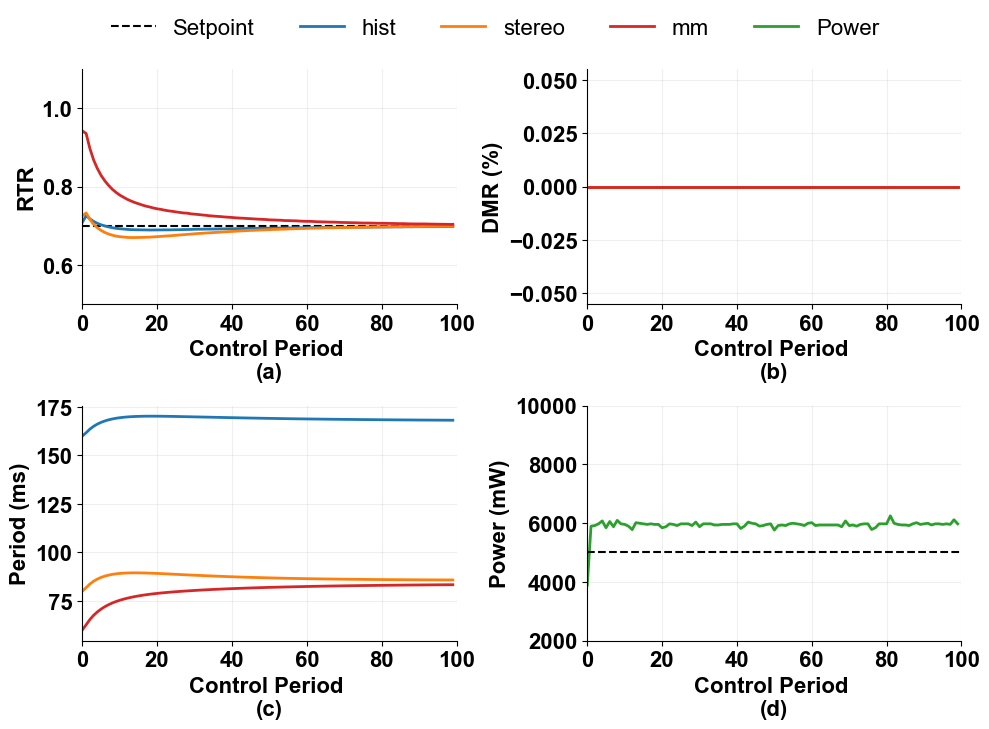

logs/Full_FC/hist_stereo_mm/setpoint_6000_0.70_0.70_0.70
5923.94


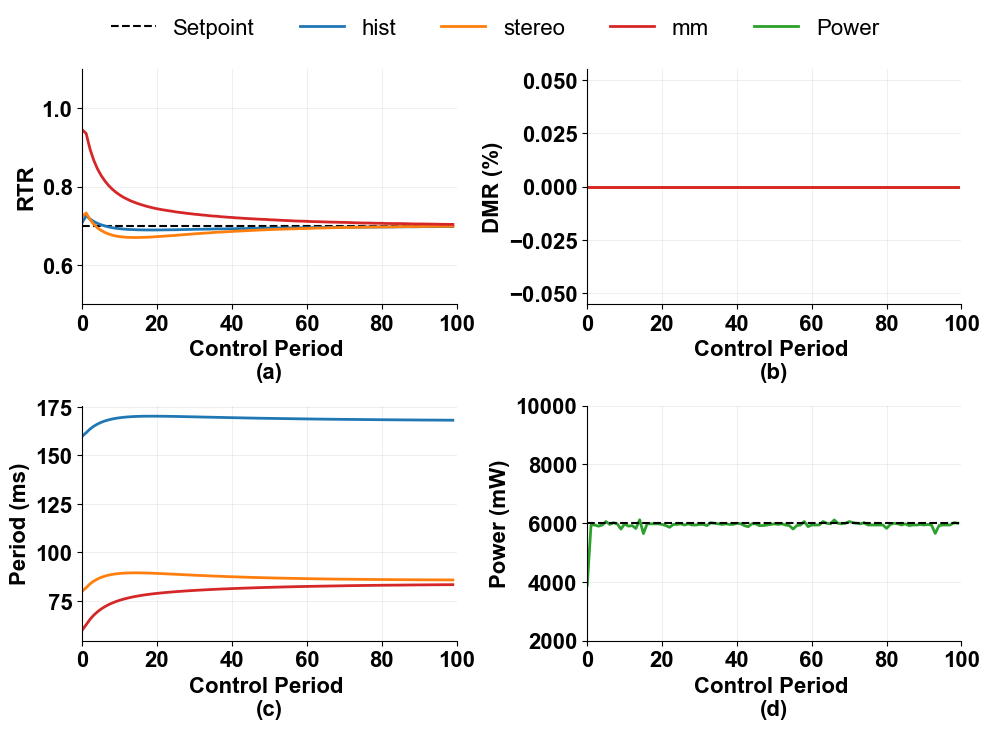

logs/Full_FC/hist_stereo_mm/setpoint_7000_0.70_0.70_0.70
5924.75


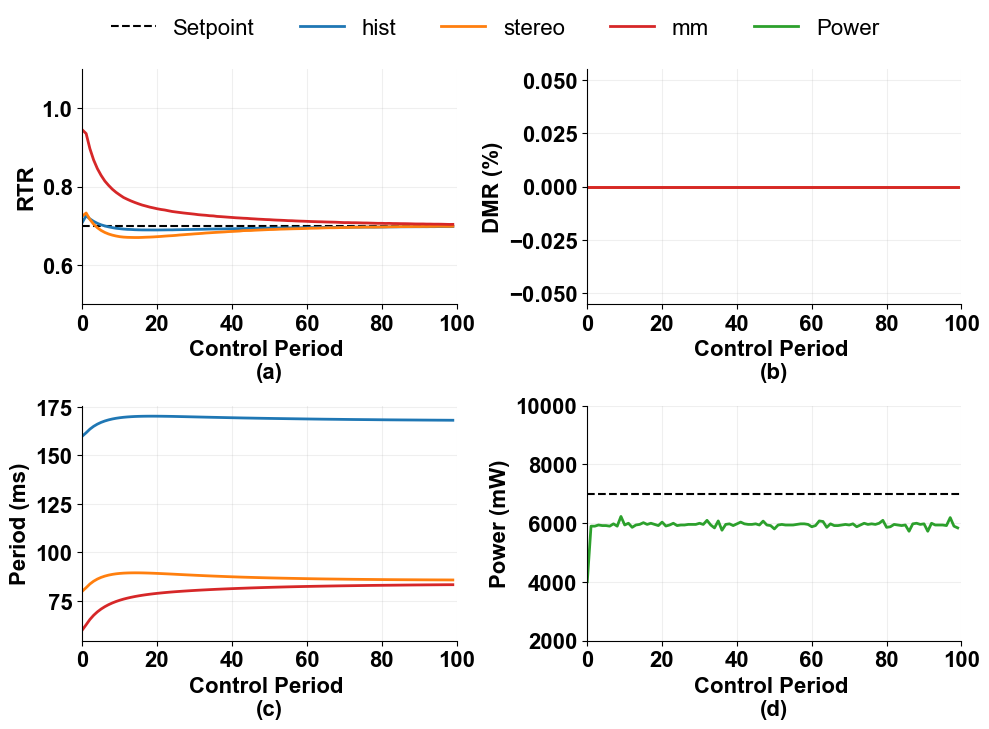

In [28]:
################FULL FC
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.weight"] = "normal"

# --------- CONFIG ----------
root = Path("logs/Full_FC/hist_stereo_mm/")  
#root = Path("Proposed_bounds/histogram_converted_stereodisparity_converted_mm_converted/") 
#oot = Path("LQR/hist_stereo_mm/") 
setpoints = [0.90, 0.80, 0.70]
p_setpoint = [5000, 6000, 7000]
warmup_skip = 0         
max_periods = 100  
save_path = Path("figures")
task_names = ["hist", "stereo", "mm"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
FIGSIZE = (10, 8)
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 16
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    for power in p_setpoint:
        run_dir = root / f"setpoint_{power}_{sp:.2f}_{sp:.2f}_{sp:.2f}"
        #run_dir = root / f"setpoint_{sp:.2f}"
        print(run_dir)
        data = {name: {} for name in task_names}
        for i, name in enumerate(task_names, 1):
            t_id = f"t{i}"
            data[name]['rtr'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_rtr.txt"), warmup_skip, max_periods)
            data[name]['dl']  = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_deadline.txt"), warmup_skip, max_periods)
            data[name]['per'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_period.txt"), warmup_skip, max_periods)
            data[name]['low'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
            data[name]['high']= slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

        pwrs = slice_idx(read_data(run_dir / "FC_GPU_finalpowervalues.txt"), warmup_skip, max_periods)

        fig, axs = plt.subplots(2, 2, figsize=FIGSIZE)
        axs = axs.flatten()
        # (1) RTR
        ax = axs[0]
        ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        for name, color in zip(task_names, task_colors):
            if data[name]['rtr'] is not None:
                ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
        ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim(0.5, 1.1)

        # (2) Deadline
        ax = axs[1]
        for name, color in zip(task_names, task_colors):
            if data[name]['dl'] is not None:
                ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
        ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        ax = axs[2]
        for name, color in zip(task_names, task_colors):
            if data[name]['per'] is not None:
                ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
            if data[name]['low'] is not None:
                #ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
            if data[name]['high'] is not None:
                #ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
        ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        # (4) Power
        ax = axs[3]
        if pwrs is not None:
            ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
        print(np.mean(pwrs))
        ax.set_ylabel("Power (mW)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.axhline(y=power, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        ax.set_ylim([2000,10000])

        # Global Styling
        for ax in axs:
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
            for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, alpha=0.2)
            ax.set_xlim([0,100])


        handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
        power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
        handles.append(power_handle)
        labels.append("Power")
#         bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
#         handles.append(bound_handle)
#         labels.append("Bounds")

        fig.legend(
            handles, 
            labels, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 0.92),  
            ncol=len(labels), 
            frameon=False, 
            prop={'size': 16} 
        )   
        plt.tight_layout(rect=[0, 0, 1, 0.85]) 

        save_path.mkdir(exist_ok=True)
        plt.savefig(save_path /f"FC_setpoint_{power}_{sp:.2f}.pdf", bbox_inches='tight')
        plt.show()

logs/Full_DFS/hist_stereo_mm/setpoint_5000_0.90_0.90_0.90
5048.395


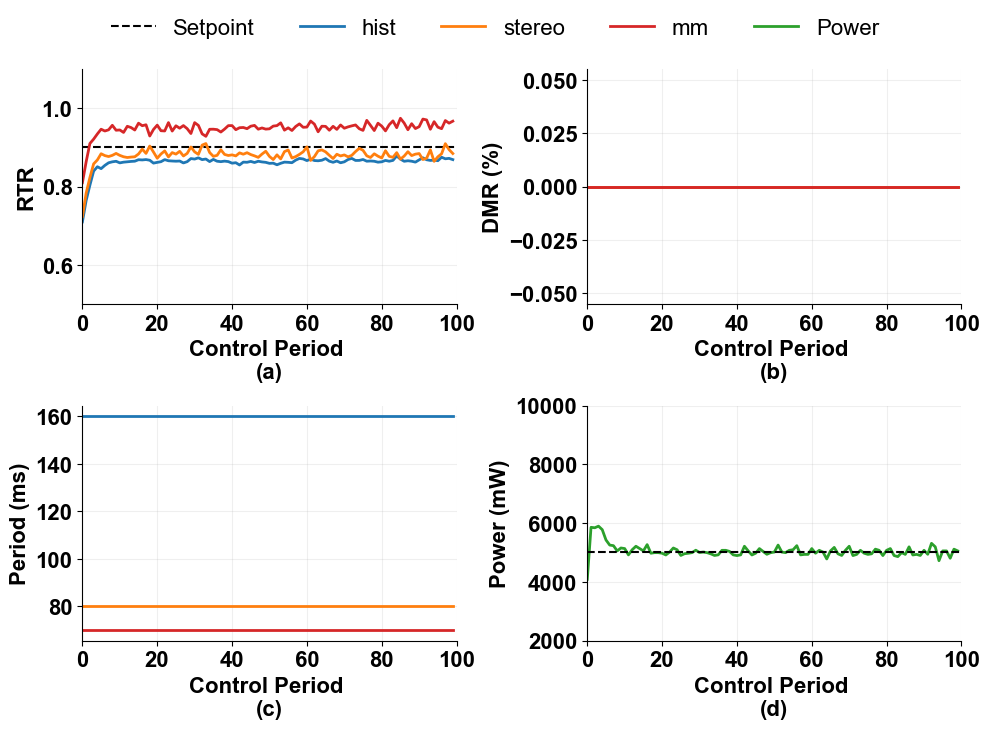

logs/Full_DFS/hist_stereo_mm/setpoint_6000_0.90_0.90_0.90
6007.855


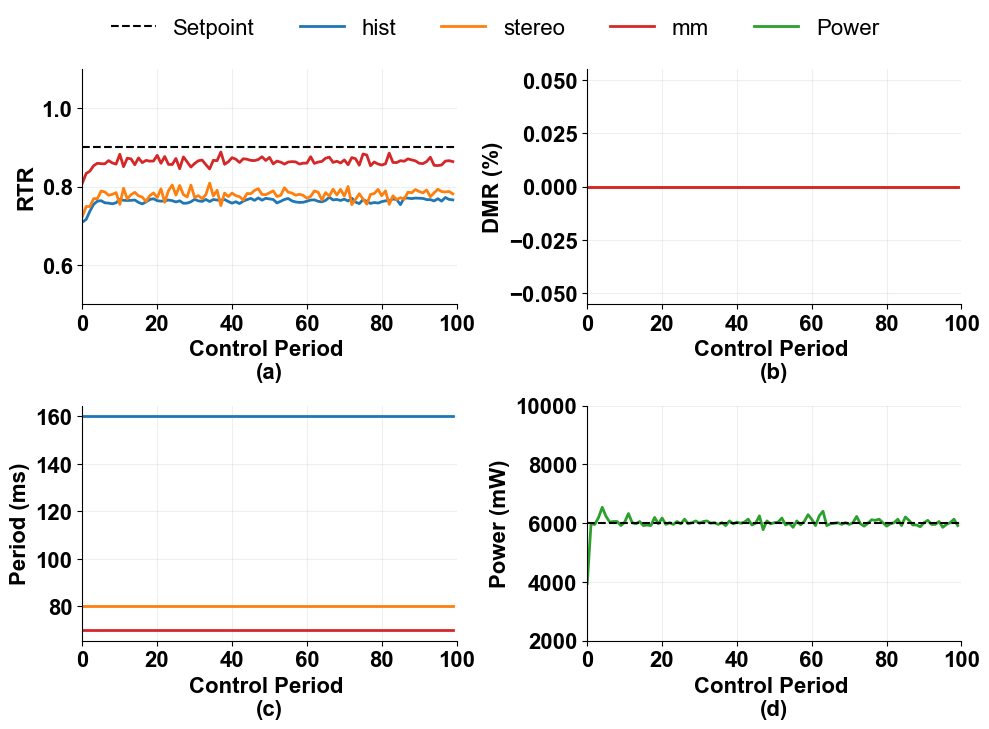

logs/Full_DFS/hist_stereo_mm/setpoint_7000_0.90_0.90_0.90
6983.27


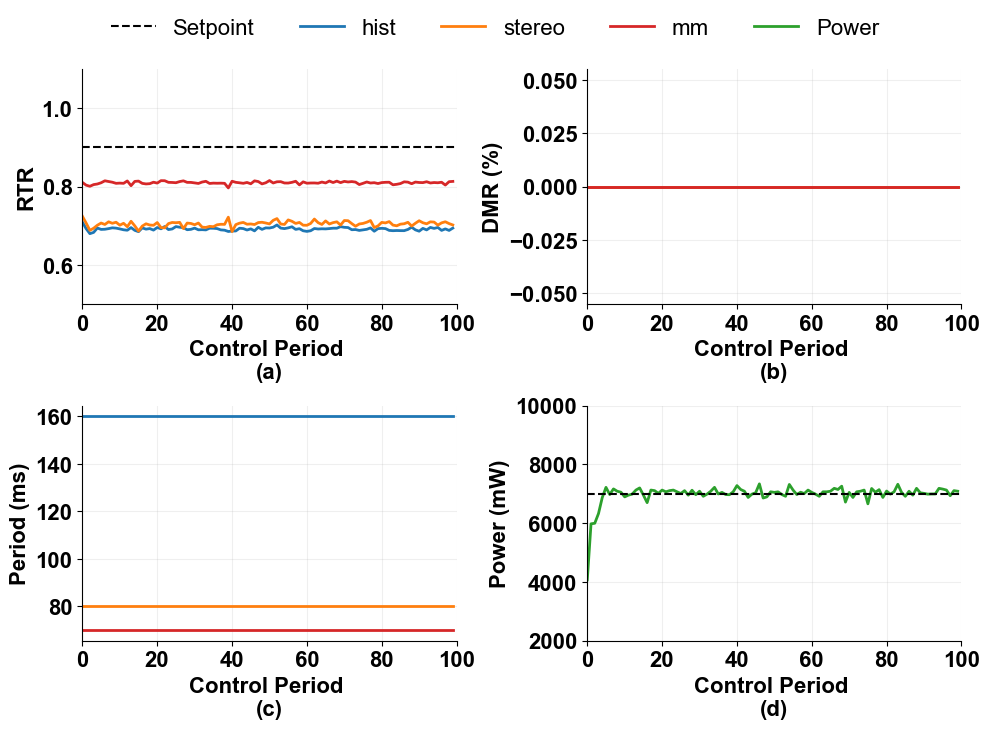

logs/Full_DFS/hist_stereo_mm/setpoint_5000_0.80_0.80_0.80


TypeError: unsupported operand type(s) for /: 'NoneType' and 'int'

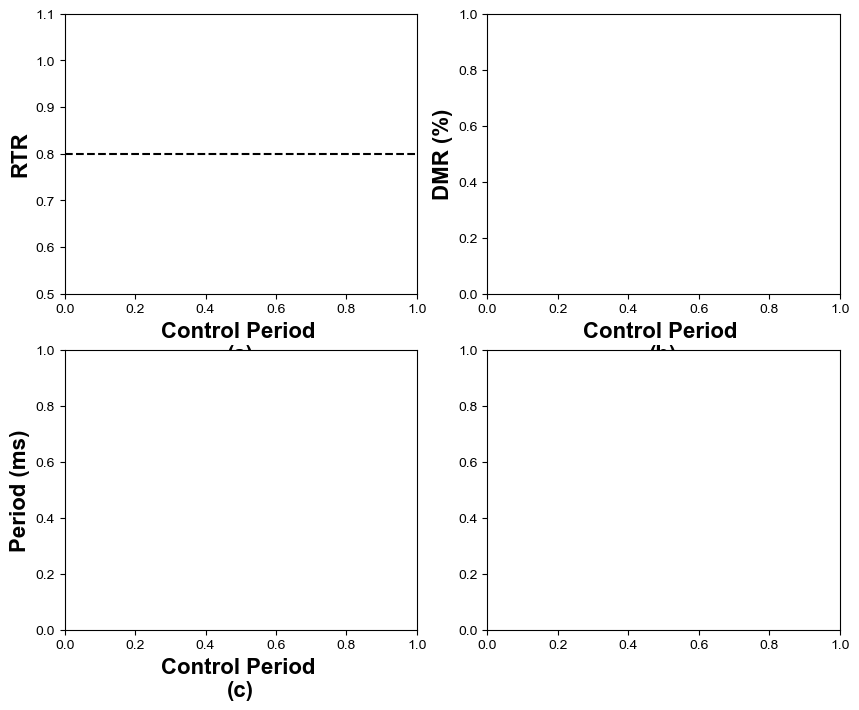

In [38]:
################FULL DFS
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.weight"] = "normal"

# --------- CONFIG ----------
root = Path("logs/Full_DFS/hist_stereo_mm/")  
#root = Path("Proposed_bounds/histogram_converted_stereodisparity_converted_mm_converted/") 
#oot = Path("LQR/hist_stereo_mm/")
setpoints = [0.90, 0.80, 0.70]
p_setpoint = [5000, 6000, 7000]
warmup_skip = 0         
max_periods = 100  
save_path = Path("figures")
task_names = ["hist", "stereo", "mm"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
FIGSIZE = (10, 8)
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 16
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    for power in p_setpoint:
        run_dir = root / f"setpoint_{power}_{sp:.2f}_{sp:.2f}_{sp:.2f}"
        #run_dir = root / f"setpoint_{sp:.2f}"
        print(run_dir)
        data = {name: {} for name in task_names}
        for i, name in enumerate(task_names, 1):
            t_id = f"t{i}"
            data[name]['rtr'] = slice_idx(read_data(run_dir / f"UNKNOWN_{t_id}_rtr.txt"), warmup_skip, max_periods)
            data[name]['dl']  = slice_idx(read_data(run_dir / f"UNKNOWN_{t_id}_deadline.txt"), warmup_skip, max_periods)
            data[name]['per'] = slice_idx(read_data(run_dir / f"UNKNOWN_{t_id}_period.txt"), warmup_skip, max_periods)
            data[name]['low'] = slice_idx(read_data(run_dir / f"UNKNOWN_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
            data[name]['high']= slice_idx(read_data(run_dir / f"UNKNOWN_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

        pwrs = slice_idx(read_data(run_dir / "UNKNOWN_finalpowervalues.txt"), warmup_skip, max_periods)

        fig, axs = plt.subplots(2, 2, figsize=FIGSIZE)
        axs = axs.flatten()

        # (1) RTR
        ax = axs[0]
        ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        for name, color in zip(task_names, task_colors):
            if data[name]['rtr'] is not None:
                ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
        ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim(0.5, 1.1)

        # (2) Deadline
        ax = axs[1]
        for name, color in zip(task_names, task_colors):
            if data[name]['dl'] is not None:
                ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
        ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        ax = axs[2]
        for name, color in zip(task_names, task_colors):
            if data[name]['per'] is not None:
                ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
            if data[name]['low'] is not None:
                #ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
            if data[name]['high'] is not None:
                #ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
        ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        # (4) Power
        ax = axs[3]
        if pwrs is not None:
            ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
        print(np.mean(pwrs))
        ax.set_ylabel("Power (mW)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.axhline(y=power, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        ax.set_ylim([2000,10000])

        # Global Styling
        for ax in axs:
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
            for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, alpha=0.2)
            ax.set_xlim([0,100])


        handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
        power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
        handles.append(power_handle)
        labels.append("Power")
        #bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
        #handles.append(bound_handle)
        #labels.append("Bounds")

        fig.legend(
            handles, 
            labels, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 0.92),  
            ncol=len(labels), 
            frameon=False, 
            prop={'size': 16} 
        )   
        plt.tight_layout(rect=[0, 0, 1, 0.85]) 

        save_path.mkdir(exist_ok=True)
        plt.savefig(save_path /f"DFS_setpoint_{power}_{sp:.2f}.pdf", bbox_inches='tight')
        plt.show()

logs/openloop/hist_stereo_mm/setpoint_0.90_0.90_0.90
6342.185


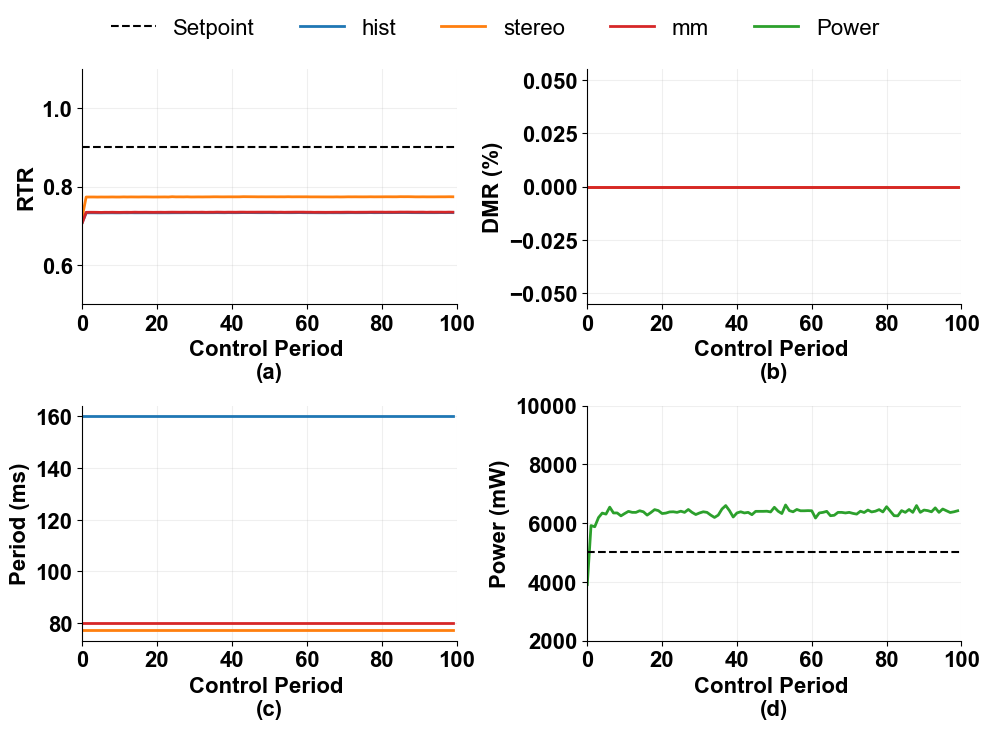

In [39]:
################ Openloop
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.weight"] = "normal"

# --------- CONFIG ----------
root = Path("logs/openloop/hist_stereo_mm/")  
#root = Path("Proposed_bounds/histogram_converted_stereodisparity_converted_mm_converted/") 
#oot = Path("LQR/hist_stereo_mm/")
setpoints = [0.90]
p_setpoint = [5000]
warmup_skip = 0         
max_periods = 100  
save_path = Path("figures")
task_names = ["hist", "stereo", "mm"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
FIGSIZE = (10, 8)
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 16
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    for power in p_setpoint:
        run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
        #run_dir = root / f"setpoint_{sp:.2f}"
        print(run_dir)
        data = {name: {} for name in task_names}
        for i, name in enumerate(task_names, 1):
            t_id = f"t{i}"
            data[name]['rtr'] = slice_idx(read_data(run_dir / f"OpenLoop_{t_id}_rtr.txt"), warmup_skip, max_periods)
            data[name]['dl']  = slice_idx(read_data(run_dir / f"OpenLoop_{t_id}_deadline.txt"), warmup_skip, max_periods)
            data[name]['per'] = slice_idx(read_data(run_dir / f"OpenLoop_{t_id}_period.txt"), warmup_skip, max_periods)
            data[name]['low'] = slice_idx(read_data(run_dir / f"OpenLoop_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
            data[name]['high']= slice_idx(read_data(run_dir / f"OpenLoop_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

        pwrs = slice_idx(read_data(run_dir / "OpenLoop_finalpowervalues.txt"), warmup_skip, max_periods)

        fig, axs = plt.subplots(2, 2, figsize=FIGSIZE)
        axs = axs.flatten()

        # (1) RTR
        ax = axs[0]
        ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        for name, color in zip(task_names, task_colors):
            if data[name]['rtr'] is not None:
                ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
        ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim(0.5, 1.1)

        # (2) Deadline
        ax = axs[1]
        for name, color in zip(task_names, task_colors):
            if data[name]['dl'] is not None:
                ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
        ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        ax = axs[2]
        for name, color in zip(task_names, task_colors):
            if data[name]['per'] is not None:
                ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
            if data[name]['low'] is not None:
                #ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
            if data[name]['high'] is not None:
                #ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
        ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        # (4) Power
        ax = axs[3]
        if pwrs is not None:
            ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
        print(np.mean(pwrs))
        ax.set_ylabel("Power (mW)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.axhline(y=power, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        ax.set_ylim([2000,10000])

        # Global Styling
        for ax in axs:
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
            for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, alpha=0.2)
            ax.set_xlim([0,100])


        handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
        power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
        handles.append(power_handle)
        labels.append("Power")
        #bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
        #handles.append(bound_handle)
        #labels.append("Bounds")

        fig.legend(
            handles, 
            labels, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 0.92),  
            ncol=len(labels), 
            frameon=False, 
            prop={'size': 16} 
        )   
        plt.tight_layout(rect=[0, 0, 1, 0.85]) 

        save_path.mkdir(exist_ok=True)
        plt.savefig(save_path /f"openloop_setpoint_{power}_{sp:.2f}.pdf", bbox_inches='tight')
        plt.show()

In [ ]:
#######FULL N+1

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# --------- CONFIG ----------
root = Path("proposed/quasirand_converted_mm_converted_bfs_converted") 
root = Path("proposed/stereodisparity_converted_mm_converted_bfs_converted")
root = Path("logs/Full_N+1/hist_stereo_mm/") 
root = Path("logs/N+1/hist_stereo_mm/") 

root = Path("logs/N+1/hist_stereo_mm_test/")
setpoints = [0.90, 0.80, 0.70]
setpoints = [0.90]
p_setpoint = [5000]
warmup_skip = 0         
max_periods = 100        
save_path = Path("figures")
task_names = ["stereo", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 16
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    print(run_dir)
    data = {name: {} for name in task_names}
    for i, name in enumerate(task_names, 1):
        t_id = f"t{i}"
        data[name]['rtr'] = slice_idx(read_data(run_dir / f"DFS_{t_id}_rtr.txt"), warmup_skip, max_periods)
        data[name]['dl']  = slice_idx(read_data(run_dir / f"DFS_{t_id}_deadline.txt"), warmup_skip, max_periods)
        data[name]['per'] = slice_idx(read_data(run_dir / f"DFS_{t_id}_period.txt"), warmup_skip, max_periods)
        data[name]['low'] = slice_idx(read_data(run_dir / f"DFS_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
        data[name]['high']= slice_idx(read_data(run_dir / f"DFS_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

    pwrs = slice_idx(read_data(run_dir / "DFS_finalpowervalues.txt"), warmup_skip, max_periods)

    fig, axs = plt.subplots(1, 4, figsize=FIGSIZE)

    # (1) RTR
    ax = axs[0]
    ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
    for name, color in zip(task_names, task_colors):
        if data[name]['rtr'] is not None:
            ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
    ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylim(0.5, 1.1)

    # (2) Deadline
    ax = axs[1]
    for name, color in zip(task_names, task_colors):
        if data[name]['dl'] is not None:
            ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
    ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

    ax = axs[2]
    for name, color in zip(task_names, task_colors):
        if data[name]['per'] is not None:
            ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
        if data[name]['low'] is not None:
            ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
        if data[name]['high'] is not None:
            ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
    ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

    # (4) Power
    ax = axs[3]
    if pwrs is not None:
        ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
    print(np.mean(pwrs))
    ax.set_ylabel("Power (mW)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.axhline(y=p_setpoint, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
    ax.set_ylim([3000,6000])

    # Global Styling
    for ax in axs:
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
        for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.2)
        ax.set_xlim([0,100])


    handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
    power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
    handles.append(power_handle)
    labels.append("Power")
    bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
    handles.append(bound_handle)
    labels.append("Bounds")

    fig.legend(
        handles, 
        labels, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.92),  
        ncol=len(labels), 
        frameon=False, 
        prop={'weight': 'bold', 'size': 14} 
    )   
    plt.tight_layout(rect=[0, 0, 1, 0.85]) 
    
    save_path.mkdir(exist_ok=True)
    plt.savefig(save_path /'proposed.pdf', bbox_inches='tight')
    plt.show()

logs/power_interrupt_LQR/hist_stereo_mm/setpoint_5000_0.90_0.90_0.90
4628.59


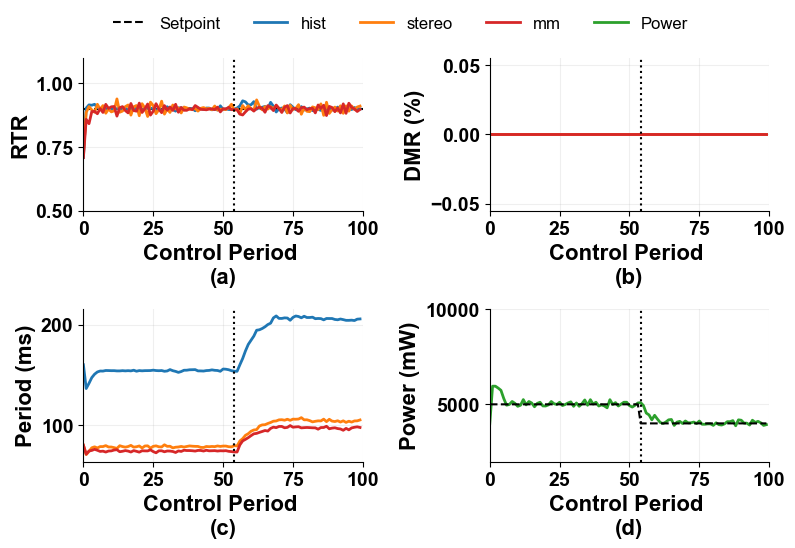

In [30]:
################Power interrupt LQR
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.weight"] = "normal"


# --------- CONFIG ----------
root = Path("logs/power_interrupt_LQR/hist_stereo_mm/")  
#root = Path("Proposed_bounds/histogram_converted_stereodisparity_converted_mm_converted/") 
#oot = Path("LQR/hist_stereo_mm/") 
setpoints = [0.90]
p_setpoint = [5000]
change_period = 54
power_after = 4000

warmup_skip = 0         
max_periods = 100  
save_path = Path("figures")
task_names = ["hist", "stereo", "mm"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
FIGSIZE = (10, 8)
FIGSIZE = (8, 6)
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 14
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    for power in p_setpoint:
        run_dir = root / f"setpoint_{power}_{sp:.2f}_{sp:.2f}_{sp:.2f}"
        #run_dir = root / f"setpoint_{sp:.2f}"
        print(run_dir)
        data = {name: {} for name in task_names}
        for i, name in enumerate(task_names, 1):
            t_id = f"t{i}"
            data[name]['rtr'] = slice_idx(read_data(run_dir / f"LQR_{t_id}_rtr.txt"), warmup_skip, max_periods)
            data[name]['dl']  = slice_idx(read_data(run_dir / f"LQR_{t_id}_deadline.txt"), warmup_skip, max_periods)
            data[name]['per'] = slice_idx(read_data(run_dir / f"LQR_{t_id}_period.txt"), warmup_skip, max_periods)
            data[name]['low'] = slice_idx(read_data(run_dir / f"LQR_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
            data[name]['high']= slice_idx(read_data(run_dir / f"LQR_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

        pwrs = slice_idx(read_data(run_dir / "LQR_finalpowervalues.txt"), warmup_skip, max_periods)

        fig, axs = plt.subplots(2, 2, figsize=FIGSIZE)
        axs = axs.flatten()
        
        # (1) RTR
        ax = axs[0]
        ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        for name, color in zip(task_names, task_colors):
            if data[name]['rtr'] is not None:
                ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
        ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim(0.5, 1.1)

        # (2) Deadline
        ax = axs[1]
        for name, color in zip(task_names, task_colors):
            if data[name]['dl'] is not None:
                ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
        ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        ax = axs[2]
        for name, color in zip(task_names, task_colors):
            if data[name]['per'] is not None:
                ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
            if data[name]['low'] is not None:
                #ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
            if data[name]['high'] is not None:
                #ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
        ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        # (4) Power
        ax = axs[3]
        if pwrs is not None:
            ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
        print(np.mean(pwrs))
        ax.set_ylabel("Power (mW)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim([2000,10000])
        power_sp = np.full(max_periods, power, dtype=float)
        power_sp[change_period:] = power_after

        ax.plot(
            power_sp,
            color='black',
            linestyle='--',
            linewidth=1.5,
            label="Setpoint"
        )


        # Global Styling
        for ax in axs:
            ax.axvline(x=change_period, color='black', linestyle=':', linewidth=1.5)
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
            for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, alpha=0.2)
            ax.set_xlim([0,100])


        handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
        power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
        handles.append(power_handle)
        labels.append("Power")
#         bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
#         handles.append(bound_handle)
#         labels.append("Bounds")

        fig.legend(
            handles, 
            labels, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 0.92),  
            ncol=len(labels), 
            frameon=False, 
            prop={ 'size': 12} 
        )   
        plt.tight_layout(rect=[0, 0, 1, 0.85]) 

        save_path.mkdir(exist_ok=True)
        plt.savefig(save_path /f"power_interrupt_LQR_setpoint_{power}_{sp:.2f}.pdf", bbox_inches='tight')
        plt.show()

logs/power_interrupt_FC/hist_stereo_mm/setpoint_5000_0.90_0.90_0.90
5953.36


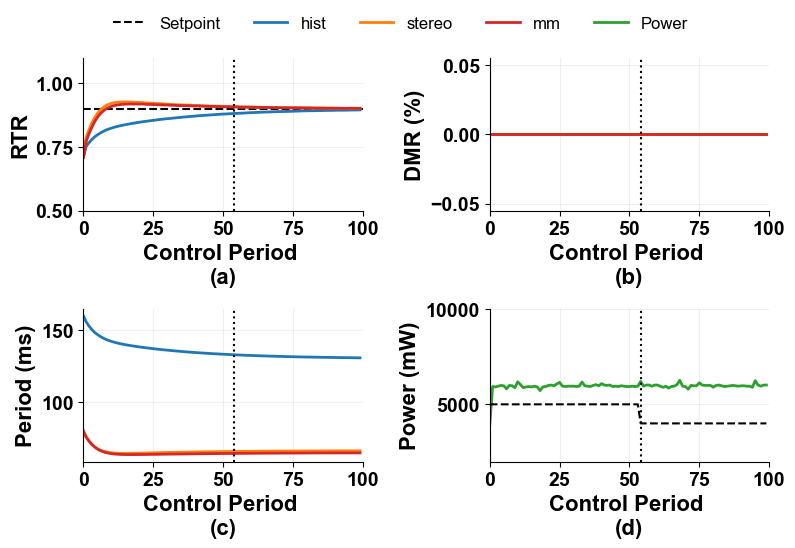

In [31]:
################Power interrupt FC
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.weight"] = "normal"


# --------- CONFIG ----------
root = Path("logs/power_interrupt_FC/hist_stereo_mm/")  
#root = Path("Proposed_bounds/histogram_converted_stereodisparity_converted_mm_converted/") 
#oot = Path("LQR/hist_stereo_mm/") 
setpoints = [0.90]
p_setpoint = [5000]
change_period = 54
power_after = 4000

warmup_skip = 0         
max_periods = 100  
save_path = Path("figures")
task_names = ["hist", "stereo", "mm"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
FIGSIZE = (10, 8)
FIGSIZE = (8, 6)
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 14
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    for power in p_setpoint:
        run_dir = root / f"setpoint_{power}_{sp:.2f}_{sp:.2f}_{sp:.2f}"
        #run_dir = root / f"setpoint_{sp:.2f}"
        print(run_dir)
        data = {name: {} for name in task_names}
        for i, name in enumerate(task_names, 1):
            t_id = f"t{i}"
            data[name]['rtr'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_rtr.txt"), warmup_skip, max_periods)
            data[name]['dl']  = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_deadline.txt"), warmup_skip, max_periods)
            data[name]['per'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_period.txt"), warmup_skip, max_periods)
            data[name]['low'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
            data[name]['high']= slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

        pwrs = slice_idx(read_data(run_dir / "FC_GPU_finalpowervalues.txt"), warmup_skip, max_periods)

        fig, axs = plt.subplots(2, 2, figsize=FIGSIZE)
        axs = axs.flatten()
        
        # (1) RTR
        ax = axs[0]
        ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        for name, color in zip(task_names, task_colors):
            if data[name]['rtr'] is not None:
                ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
        ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim(0.5, 1.1)

        # (2) Deadline
        ax = axs[1]
        for name, color in zip(task_names, task_colors):
            if data[name]['dl'] is not None:
                ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
        ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        ax = axs[2]
        for name, color in zip(task_names, task_colors):
            if data[name]['per'] is not None:
                ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
            if data[name]['low'] is not None:
                #ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
            if data[name]['high'] is not None:
               # ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
        ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        # (4) Power
        ax = axs[3]
        if pwrs is not None:
            ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
        print(np.mean(pwrs))
        ax.set_ylabel("Power (mW)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim([2000,10000])
        power_sp = np.full(max_periods, power, dtype=float)
        power_sp[change_period:] = power_after

        ax.plot(
            power_sp,
            color='black',
            linestyle='--',
            linewidth=1.5,
            label="Setpoint"
        )


        # Global Styling
        for ax in axs:
            ax.axvline(x=change_period, color='black', linestyle=':', linewidth=1.5)
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
            for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, alpha=0.2)
            ax.set_xlim([0,100])


        handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
        power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
        handles.append(power_handle)
        labels.append("Power")
#         bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
#         handles.append(bound_handle)
#         labels.append("Bounds")

        fig.legend(
            handles, 
            labels, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 0.92),  
            ncol=len(labels), 
            frameon=False, 
            prop={ 'size': 12} 
        )   
        plt.tight_layout(rect=[0, 0, 1, 0.85]) 

        save_path.mkdir(exist_ok=True)
        plt.savefig(save_path /f"power_interrupt_FC_setpoint_{power}_{sp:.2f}.pdf", bbox_inches='tight')
        plt.show()

logs/power_interrupt_DFS/hist_stereo_mm/setpoint_5000_0.90_0.90_0.90
4638.08


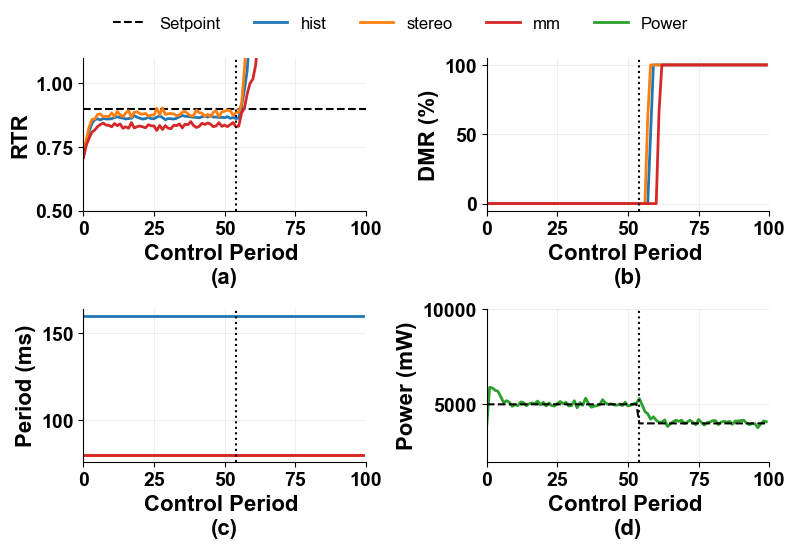

In [32]:
################Power interrupt DFS
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.weight"] = "normal"


# --------- CONFIG ----------
root = Path("logs/power_interrupt_DFS/hist_stereo_mm/")  
#root = Path("Proposed_bounds/histogram_converted_stereodisparity_converted_mm_converted/") 
#oot = Path("LQR/hist_stereo_mm/") 
setpoints = [0.90]
p_setpoint = [5000]
change_period = 54
power_after = 4000

warmup_skip = 0         
max_periods = 100  
save_path = Path("figures")
task_names = ["hist", "stereo", "mm"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
FIGSIZE = (10, 8)
FIGSIZE = (8, 6)
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 14
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    for power in p_setpoint:
        run_dir = root / f"setpoint_{power}_{sp:.2f}_{sp:.2f}_{sp:.2f}"
        #run_dir = root / f"setpoint_{sp:.2f}"
        print(run_dir)
        data = {name: {} for name in task_names}
        for i, name in enumerate(task_names, 1):
            t_id = f"t{i}"
            data[name]['rtr'] = slice_idx(read_data(run_dir / f"DFS_{t_id}_rtr.txt"), warmup_skip, max_periods)
            data[name]['dl']  = slice_idx(read_data(run_dir / f"DFS_{t_id}_deadline.txt"), warmup_skip, max_periods)
            data[name]['per'] = slice_idx(read_data(run_dir / f"DFS_{t_id}_period.txt"), warmup_skip, max_periods)
            data[name]['low'] = slice_idx(read_data(run_dir / f"DFS_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
            data[name]['high']= slice_idx(read_data(run_dir / f"DFS_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

        pwrs = slice_idx(read_data(run_dir / "DFS_finalpowervalues.txt"), warmup_skip, max_periods)

        fig, axs = plt.subplots(2, 2, figsize=FIGSIZE)
        axs = axs.flatten()
        
        # (1) RTR
        ax = axs[0]
        ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        for name, color in zip(task_names, task_colors):
            if data[name]['rtr'] is not None:
                ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
        ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim(0.5, 1.1)

        # (2) Deadline
        ax = axs[1]
        for name, color in zip(task_names, task_colors):
            if data[name]['dl'] is not None:
                ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
        ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        ax = axs[2]
        for name, color in zip(task_names, task_colors):
            if data[name]['per'] is not None:
                ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
            if data[name]['low'] is not None:
                #ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
            if data[name]['high'] is not None:
                #ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
        ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        # (4) Power
        ax = axs[3]
        if pwrs is not None:
            ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
        print(np.mean(pwrs))
        ax.set_ylabel("Power (mW)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim([2000,10000])
        power_sp = np.full(max_periods, power, dtype=float)
        power_sp[change_period:] = power_after

        ax.plot(
            power_sp,
            color='black',
            linestyle='--',
            linewidth=1.5,
            label="Setpoint"
        )


        # Global Styling
        for ax in axs:
            ax.axvline(x=change_period, color='black', linestyle=':', linewidth=1.5)
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
            for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, alpha=0.2)
            ax.set_xlim([0,100])


        handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
        power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
        handles.append(power_handle)
        labels.append("Power")
#         bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
#         handles.append(bound_handle)
#         labels.append("Bounds")

        fig.legend(
            handles, 
            labels, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 0.92),  
            ncol=len(labels), 
            frameon=False, 
            prop={ 'size': 12} 
        )   
        plt.tight_layout(rect=[0, 0, 1, 0.85]) 

        save_path.mkdir(exist_ok=True)
        plt.savefig(save_path /f"power_interrupt_DFS_setpoint_{power}_{sp:.2f}.pdf", bbox_inches='tight')
        plt.show()

logs/LQR_interrupt/hist_stereo_mm_test/setpoint_0.90_0.90_0.90
5058.875


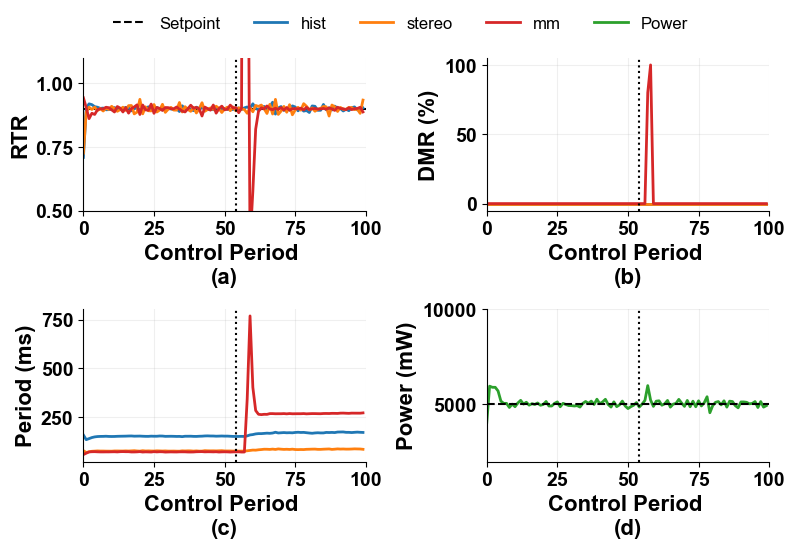

In [54]:
################MM interrupt LQR
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.weight"] = "normal"


# --------- CONFIG ----------
root = Path("logs/LQR_interrupt/hist_stereo_mm_test/")  
#root = Path("Proposed_bounds/histogram_converted_stereodisparity_converted_mm_converted/") 
#oot = Path("LQR/hist_stereo_mm/") 
setpoints = [0.90]
p_setpoint = [5000]
change_period = 54

warmup_skip = 0         
max_periods = 100  
save_path = Path("figures")
task_names = ["hist", "stereo", "mm"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
FIGSIZE = (10, 8)
FIGSIZE = (8, 6)
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 14
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    for power in p_setpoint:
        run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
        #run_dir = root / f"setpoint_{sp:.2f}"
        print(run_dir)
        data = {name: {} for name in task_names}
        for i, name in enumerate(task_names, 1):
            t_id = f"t{i}"
            data[name]['rtr'] = slice_idx(read_data(run_dir / f"LQR_{t_id}_rtr.txt"), warmup_skip, max_periods)
            data[name]['dl']  = slice_idx(read_data(run_dir / f"LQR_{t_id}_deadline.txt"), warmup_skip, max_periods)
            data[name]['per'] = slice_idx(read_data(run_dir / f"LQR_{t_id}_period.txt"), warmup_skip, max_periods)
            data[name]['low'] = slice_idx(read_data(run_dir / f"LQR_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
            data[name]['high']= slice_idx(read_data(run_dir / f"LQR_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

        pwrs = slice_idx(read_data(run_dir / "LQR_finalpowervalues.txt"), warmup_skip, max_periods)

        fig, axs = plt.subplots(2, 2, figsize=FIGSIZE)
        axs = axs.flatten()
        
        # (1) RTR
        ax = axs[0]
        ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        for name, color in zip(task_names, task_colors):
            if data[name]['rtr'] is not None:
                ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
        ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim(0.5, 1.1)

        # (2) Deadline
        ax = axs[1]
        for name, color in zip(task_names, task_colors):
            if data[name]['dl'] is not None:
                ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
        ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        ax = axs[2]
        for name, color in zip(task_names, task_colors):
            if data[name]['per'] is not None:
                ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
            if data[name]['low'] is not None:
                #ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
            if data[name]['high'] is not None:
                #ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
        ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        # (4) Power
        ax = axs[3]
        if pwrs is not None:
            ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
        print(np.mean(pwrs))
        ax.set_ylabel("Power (mW)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim([2000,10000])
        ax.axhline(y=power, color='black', linestyle='--', linewidth=1.5, label="Setpoint")



        # Global Styling
        for ax in axs:
            ax.axvline(x=change_period, color='black', linestyle=':', linewidth=1.5)
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
            for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, alpha=0.2)
            ax.set_xlim([0,100])


        handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
        power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
        handles.append(power_handle)
        labels.append("Power")
#         bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
#         handles.append(bound_handle)
#         labels.append("Bounds")

        fig.legend(
            handles, 
            labels, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 0.92),  
            ncol=len(labels), 
            frameon=False, 
            prop={ 'size': 12} 
        )   
        plt.tight_layout(rect=[0, 0, 1, 0.85]) 

        save_path.mkdir(exist_ok=True)
        plt.savefig(save_path /f"mm_interrupt_LQR_{power}_{sp:.2f}.pdf", bbox_inches='tight')
        plt.show()

logs/FC_interrupt/hist_stereo_mm_test/setpoint_0.90_0.90_0.90
6274.74


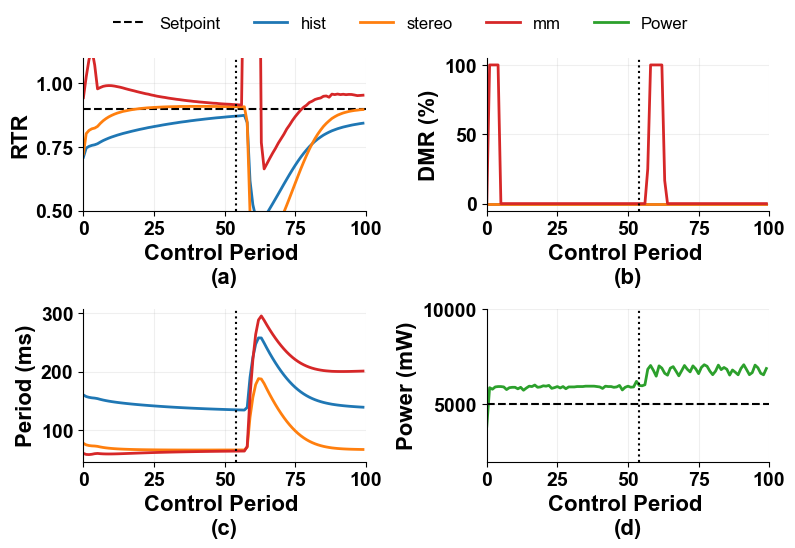

In [53]:
################ interrupt FC
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.weight"] = "normal"


# --------- CONFIG ----------
root = Path("logs/FC_interrupt/hist_stereo_mm_test/")  
#root = Path("Proposed_bounds/histogram_converted_stereodisparity_converted_mm_converted/") 
#oot = Path("LQR/hist_stereo_mm/") 
setpoints = [0.90]
p_setpoint = [5000]
change_period = 54

warmup_skip = 0         
max_periods = 100  
save_path = Path("figures")
task_names = ["hist", "stereo", "mm"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
FIGSIZE = (10, 8)
FIGSIZE = (8, 6)
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 14
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    for power in p_setpoint:
        run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
        #run_dir = root / f"setpoint_{sp:.2f}"
        print(run_dir)
        data = {name: {} for name in task_names}
        for i, name in enumerate(task_names, 1):
            t_id = f"t{i}"
            data[name]['rtr'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_rtr.txt"), warmup_skip, max_periods)
            data[name]['dl']  = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_deadline.txt"), warmup_skip, max_periods)
            data[name]['per'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_period.txt"), warmup_skip, max_periods)
            data[name]['low'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
            data[name]['high']= slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

        pwrs = slice_idx(read_data(run_dir / "FC_GPU_finalpowervalues.txt"), warmup_skip, max_periods)

        fig, axs = plt.subplots(2, 2, figsize=FIGSIZE)
        axs = axs.flatten()
        
        # (1) RTR
        ax = axs[0]
        ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        for name, color in zip(task_names, task_colors):
            if data[name]['rtr'] is not None:
                ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
        ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim(0.5, 1.1)

        # (2) Deadline
        ax = axs[1]
        for name, color in zip(task_names, task_colors):
            if data[name]['dl'] is not None:
                ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
        ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        ax = axs[2]
        for name, color in zip(task_names, task_colors):
            if data[name]['per'] is not None:
                ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
            if data[name]['low'] is not None:
                #ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
            if data[name]['high'] is not None:
               # ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
        ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        # (4) Power
        ax = axs[3]
        if pwrs is not None:
            ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
        print(np.mean(pwrs))
        ax.set_ylabel("Power (mW)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim([2000,10000])
        ax.axhline(y=power, color='black', linestyle='--', linewidth=1.5, label="Setpoint")


        # Global Styling
        for ax in axs:
            ax.axvline(x=change_period, color='black', linestyle=':', linewidth=1.5)
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
            for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, alpha=0.2)
            ax.set_xlim([0,100])


        handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
        power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
        handles.append(power_handle)
        labels.append("Power")
#         bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
#         handles.append(bound_handle)
#         labels.append("Bounds")

        fig.legend(
            handles, 
            labels, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 0.92),  
            ncol=len(labels), 
            frameon=False, 
            prop={ 'size': 12} 
        )   
        plt.tight_layout(rect=[0, 0, 1, 0.85]) 

        save_path.mkdir(exist_ok=True)
        plt.savefig(save_path /f"mm_interrupt_FC_{power}_{sp:.2f}.pdf", bbox_inches='tight')
        plt.show()

logs/DFS_interrupt/hist_stereo_mm_test/setpoint_0.90_0.90_0.90
5076.14


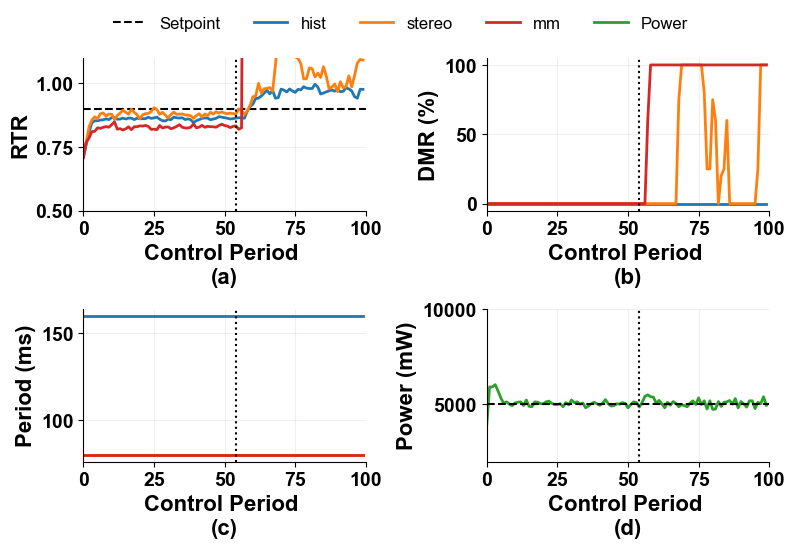

In [52]:
################ interrupt DFS
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.weight"] = "normal"


# --------- CONFIG ----------
root = Path("logs/DFS_interrupt/hist_stereo_mm_test/")  
#root = Path("Proposed_bounds/histogram_converted_stereodisparity_converted_mm_converted/") 
#oot = Path("LQR/hist_stereo_mm/") 
setpoints = [0.90]
p_setpoint = [5000]
change_period = 54


warmup_skip = 0         
max_periods = 100  
save_path = Path("figures")
task_names = ["hist", "stereo", "mm"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
FIGSIZE = (10, 8)
FIGSIZE = (8, 6)
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 14
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    for power in p_setpoint:
        run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
        #run_dir = root / f"setpoint_{sp:.2f}"
        print(run_dir)
        data = {name: {} for name in task_names}
        for i, name in enumerate(task_names, 1):
            t_id = f"t{i}"
            data[name]['rtr'] = slice_idx(read_data(run_dir / f"DFS_{t_id}_rtr.txt"), warmup_skip, max_periods)
            data[name]['dl']  = slice_idx(read_data(run_dir / f"DFS_{t_id}_deadline.txt"), warmup_skip, max_periods)
            data[name]['per'] = slice_idx(read_data(run_dir / f"DFS_{t_id}_period.txt"), warmup_skip, max_periods)
            data[name]['low'] = slice_idx(read_data(run_dir / f"DFS_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
            data[name]['high']= slice_idx(read_data(run_dir / f"DFS_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

        pwrs = slice_idx(read_data(run_dir / "DFS_finalpowervalues.txt"), warmup_skip, max_periods)

        fig, axs = plt.subplots(2, 2, figsize=FIGSIZE)
        axs = axs.flatten()
        
        # (1) RTR
        ax = axs[0]
        ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        for name, color in zip(task_names, task_colors):
            if data[name]['rtr'] is not None:
                ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
        ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim(0.5, 1.1)

        # (2) Deadline
        ax = axs[1]
        for name, color in zip(task_names, task_colors):
            if data[name]['dl'] is not None:
                ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
        ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        ax = axs[2]
        for name, color in zip(task_names, task_colors):
            if data[name]['per'] is not None:
                ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
            if data[name]['low'] is not None:
                #ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
            if data[name]['high'] is not None:
                #ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
                pass
        ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

        # (4) Power
        ax = axs[3]
        if pwrs is not None:
            ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
        print(np.mean(pwrs))
        ax.set_ylabel("Power (mW)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax.set_ylim([2000,10000])
        ax.axhline(y=power, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
        


        # Global Styling
        for ax in axs:
            ax.axvline(x=change_period, color='black', linestyle=':', linewidth=1.5)
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
            for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, alpha=0.2)
            ax.set_xlim([0,100])


        handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
        power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
        handles.append(power_handle)
        labels.append("Power")
#         bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
#         handles.append(bound_handle)
#         labels.append("Bounds")

        fig.legend(
            handles, 
            labels, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 0.92),  
            ncol=len(labels), 
            frameon=False, 
            prop={ 'size': 12} 
        )   
        plt.tight_layout(rect=[0, 0, 1, 0.85]) 

        save_path.mkdir(exist_ok=True)
        plt.savefig(save_path /f"mm_interrupt_DFS_{power}_{sp:.2f}.pdf", bbox_inches='tight')
        plt.show()

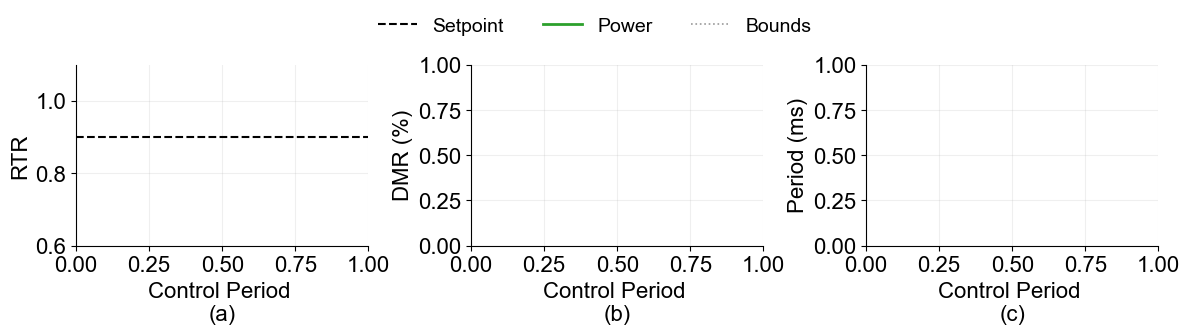

logs/Full_N+1/hist_stereo_mm/setpoint_5000_0.90_0.90_0.90
5156.935


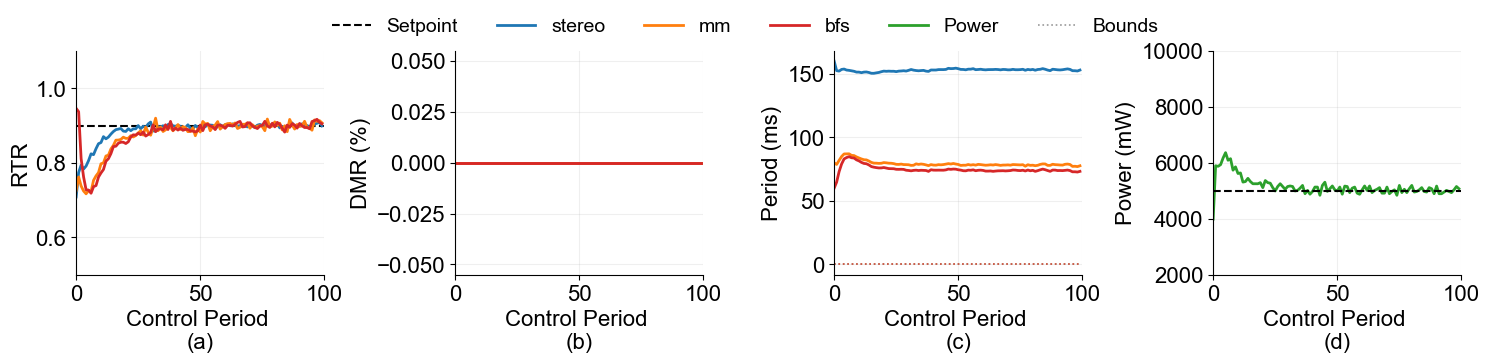

logs/Full_N+1/hist_stereo_mm/setpoint_6000_0.90_0.90_0.90
6007.95


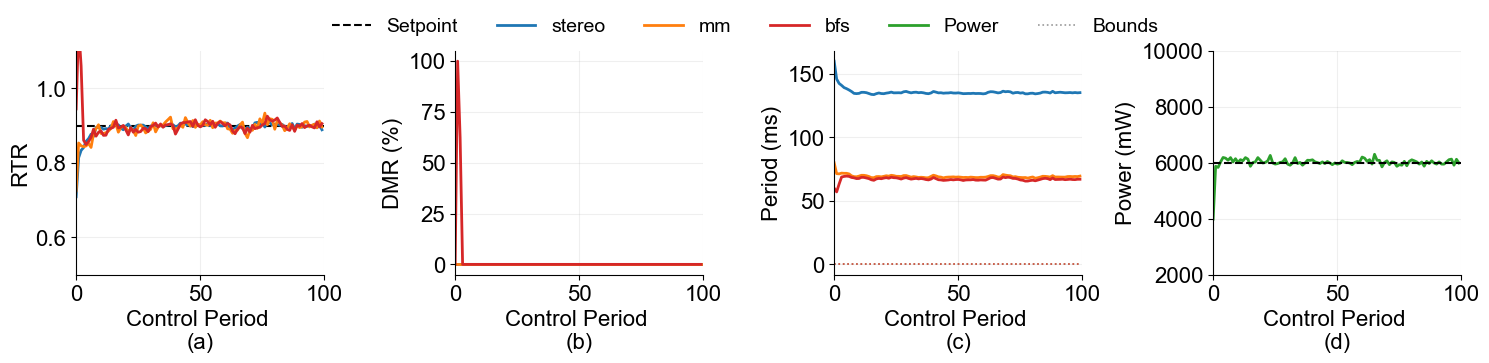

logs/Full_N+1/hist_stereo_mm/setpoint_7000_0.90_0.90_0.90
6884.075


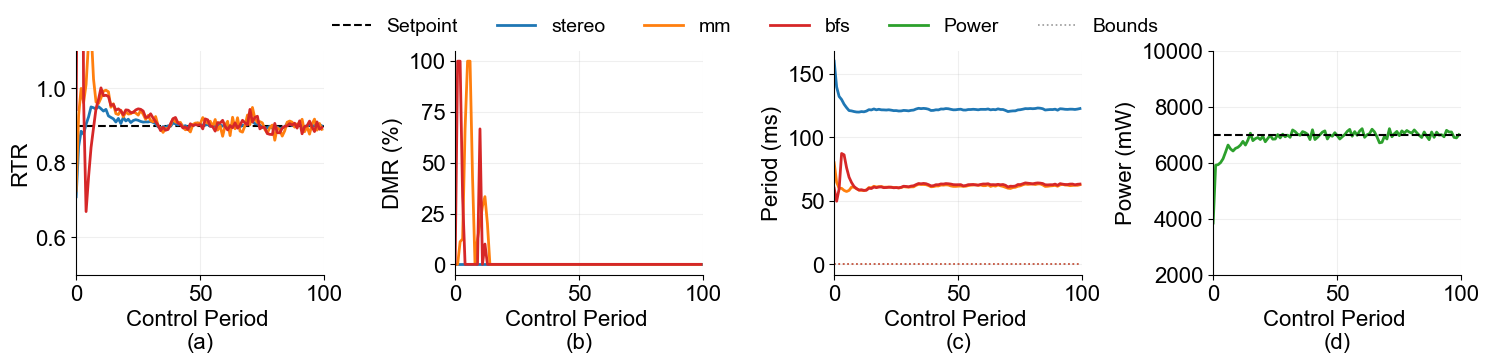

logs/Full_N+1/hist_stereo_mm/setpoint_5000_0.80_0.80_0.80
5165.105


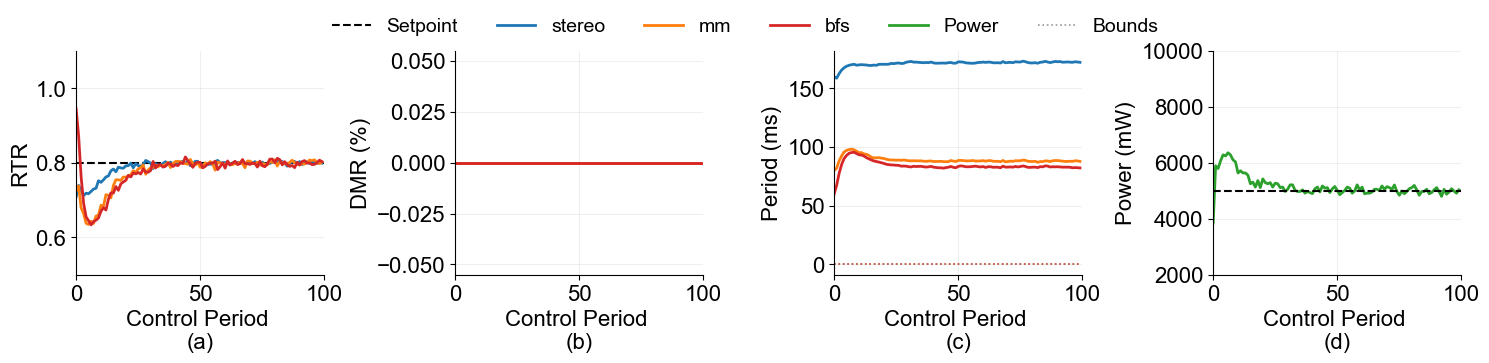

logs/Full_N+1/hist_stereo_mm/setpoint_6000_0.80_0.80_0.80
6035.42


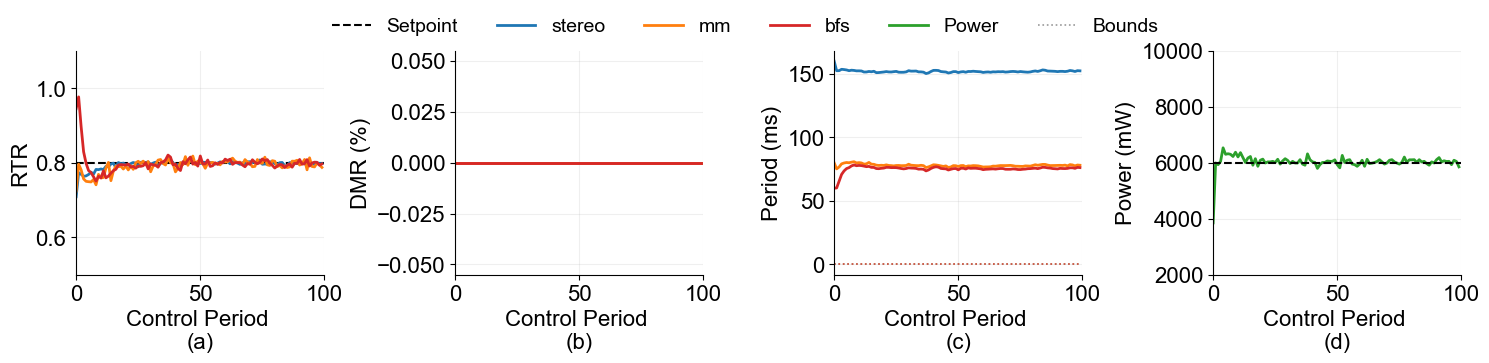

logs/Full_N+1/hist_stereo_mm/setpoint_7000_0.80_0.80_0.80
6892.04


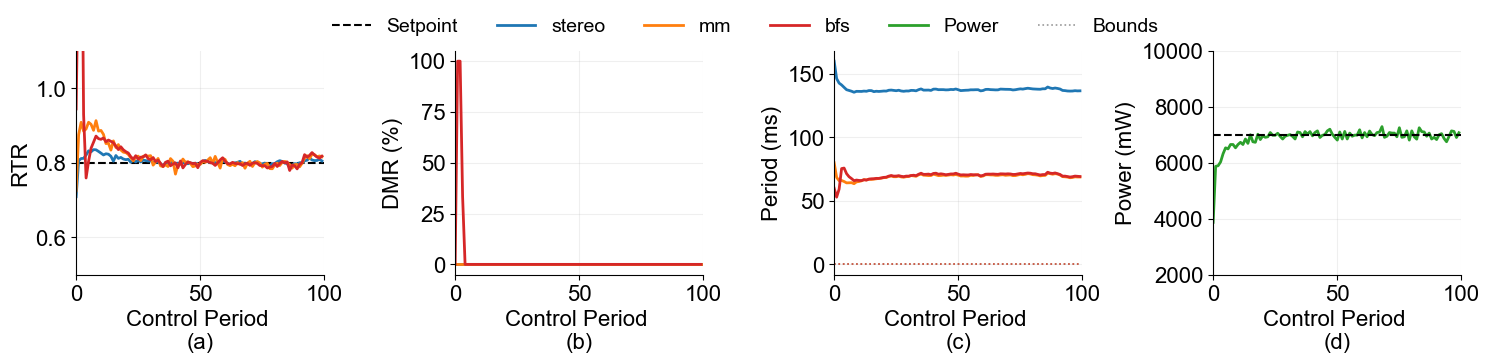

logs/Full_N+1/hist_stereo_mm/setpoint_5000_0.70_0.70_0.70
5186.875


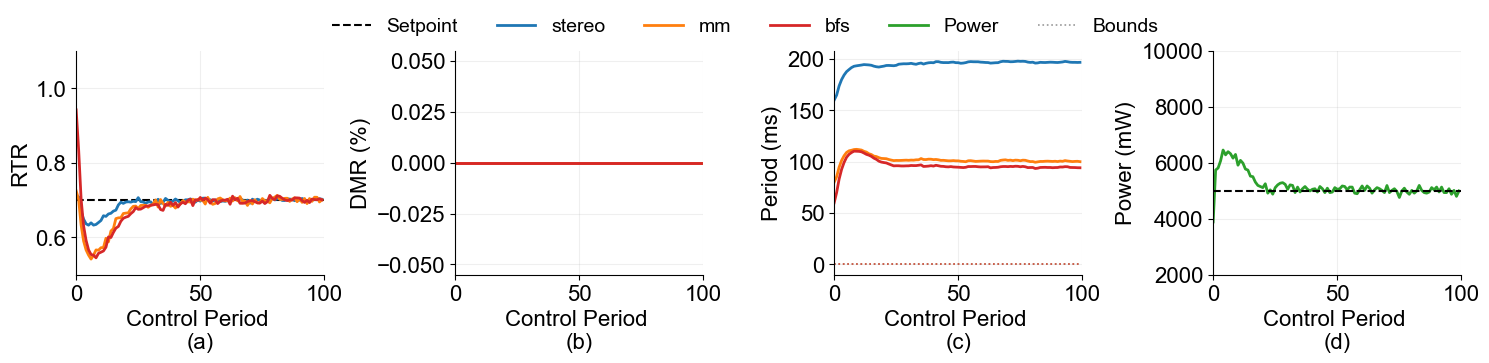

logs/Full_N+1/hist_stereo_mm/setpoint_6000_0.70_0.70_0.70
6054.915


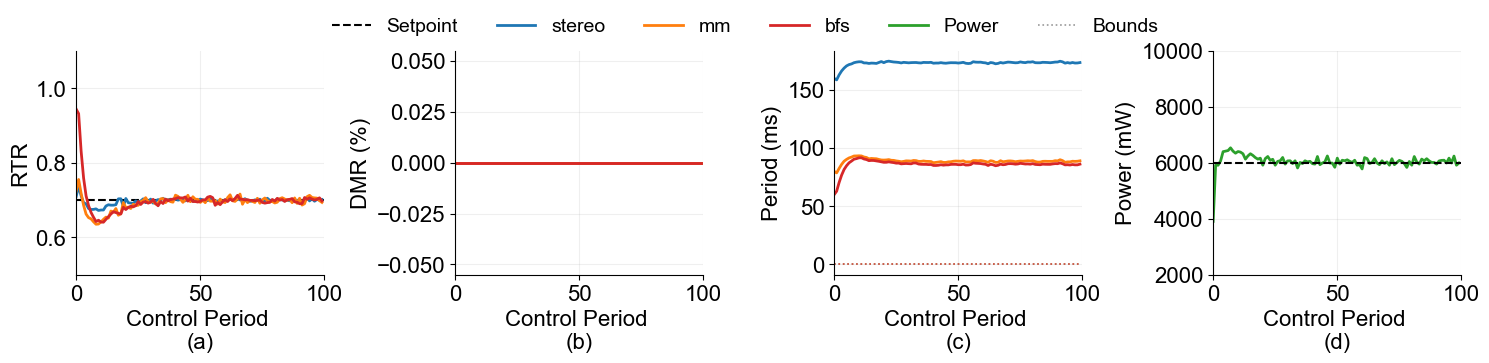

logs/Full_N+1/hist_stereo_mm/setpoint_7000_0.70_0.70_0.70
6925.965


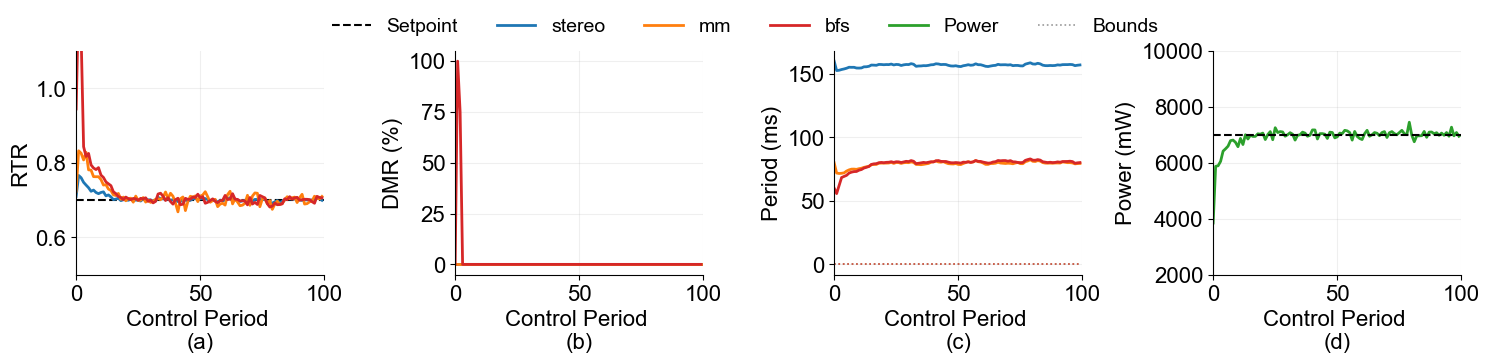